# [셀 0] Qwen2.5-Coder-3B Unity Assistant — QLoRA Fine-tuning (Google Colab A100)

**파이프라인 순서**
1. 환경 설정 & 의존성 설치
2. Google Drive 마운트 & 프로젝트 파일 설정
3. **Base Model 평가** (학습 전 베이스라인)
4. **QLoRA 학습** (A100 최적화)
5. **Fine-tuned Model 평가** (학습 후)
6. **모델 비교 & 결과 저장** (CSV / JSON / Markdown / PNG)
7. **GGUF 변환 & Q4_K_M 양자화**
8. **llama.cpp 추론 테스트**

> **런타임 설정**: 런타임 → 런타임 유형 변경 → **A100 GPU** 선택
>
> **A100 사양**: BF16 + TF32 지원, Flash Attention 2 지원(CC 8.0), VRAM 40GB
>
> **A100 최적화 요약**: TF32 matmul 가속 · Flash Attention 2 · BF16 · adamw_torch_fused · batch 4 × grad_accum 8 (effective 32) · max_len 4096

In [ ]:
# ── [셀 1] 0. GPU / 환경 확인 (A100 권장) ──────────────────────────────────────────
import subprocess, os, sys

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')

if torch.cuda.is_available():
    name  = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    print(f'GPU      : {name}')
    print(f'VRAM     : {props.total_memory / 1e9:.1f} GB')
    print(f'CC       : {props.major}.{props.minor}')
    print(f'BF16     : {torch.cuda.is_bf16_supported()}')

    # ── A100 환경 확인 ────────────────────────────────────────────────────
    if 'A100' in name:
        print('\n[OK] A100 감지 — BF16 / TF32 / Flash Attention 2 모두 사용 가능')
    elif props.major >= 8:
        print(f'\n[INFO] Ampere 이상 GPU({name}) — A100 최적화 설정 그대로 적용 가능')
    else:
        print(f'\n[WARN] {name} 은(는) A100이 아닙니다 (CC {props.major}.{props.minor}).')
        print('       이 노트북은 A100(40GB) 기준으로 튜닝되어 있습니다.')
        print('       런타임 → 런타임 유형 변경 → A100 GPU 선택을 권장합니다.')
        print('       (현재 GPU로도 동작하지만 batch/seq_len/Flash-Attn이 자동 하향됩니다.)')
else:
    print('GPU      : N/A — 런타임 유형을 GPU(A100)로 변경하세요.')

In [ ]:
# ── [셀 2] 1. Google Drive 마운트 ────────────────────────────────────────────────────
import os
from google.colab import drive
drive.mount('/content/drive')

# ── 프로젝트 경로 설정 ────────────────────────────────────────────────────────
# Drive에 프로젝트 파일을 업로드한 폴더 경로를 여기서 지정하세요
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/unity-lm'   # Drive 내 프로젝트 소스 경로
PROJECT_DIR       = '/content/unity-lm'                                  # Colab 로컬 작업 경로

# Colab 로컬 파일 시스템 내 출력 디렉토리 (PROJECT_DIR 기준)
OUTPUT_DIR        = f'{PROJECT_DIR}/output'
LORA_DIR          = f'{OUTPUT_DIR}/lora_adapter'
MERGED_DIR        = f'{OUTPUT_DIR}/merged_model'
EVAL_DIR          = f'{PROJECT_DIR}/evaluation'
GGUF_DIR          = f'{OUTPUT_DIR}'
LLAMA_CPP_DIR     = f'{PROJECT_DIR}/llama-cpp-colab'

for d in [PROJECT_DIR, OUTPUT_DIR, EVAL_DIR, LLAMA_CPP_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'PROJECT_DIR : {PROJECT_DIR}')
print(f'DRIVE_DIR   : {DRIVE_PROJECT_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR : /content/unity-lm
DRIVE_DIR   : /content/drive/MyDrive/Colab Notebooks/unity-lm


In [ ]:
# ── [셀 3] 2. 프로젝트 파일 복사 (Drive → Colab) ────────────────────────────────────
import shutil

FILES_TO_COPY = [
    'train.py', 'dataset.py', 'monitor.py',
    'export_gguf.py', 'merge_lora.py'
]

for fname in FILES_TO_COPY:
    src = os.path.join(DRIVE_PROJECT_DIR, fname)
    dst = os.path.join(PROJECT_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f'[COPY] {fname}')
    else:
        print(f'[SKIP] {fname} 없음 — Drive 경로 확인: {src}')

# Drive 출력 루트 = 프로젝트 폴더 자체
# output/, evaluation/ 을 DRIVE_PROJECT_DIR 바로 아래에 생성
DRIVE_OUT = DRIVE_PROJECT_DIR
os.makedirs(LORA_DIR, exist_ok=True)

# [FIX-5] LoRA 어댑터 복원: 경로를 output_colab/lora_adapter로 통일
lora_src = os.path.join(DRIVE_OUT, 'output', 'lora_adapter')
if os.path.isdir(lora_src):
    shutil.copytree(lora_src, LORA_DIR, dirs_exist_ok=True)
    print(f'[RESTORE] LoRA 어댑터 복원: {LORA_DIR}')

# [FIX-5] 체크포인트 복원 (최신 1개 → train.py가 자동으로 resume)
import glob as _glob
ckpt_pattern = os.path.join(DRIVE_OUT, 'output', 'checkpoint-*')
drive_ckpts = sorted(
    _glob.glob(ckpt_pattern),
    key=lambda p: int(p.rsplit('-', 1)[-1]) if p.rsplit('-', 1)[-1].isdigit() else 0
)
if drive_ckpts:
    latest = drive_ckpts[-1]
    dst_ckpt = os.path.join(LORA_DIR, os.path.basename(latest))
    shutil.copytree(latest, dst_ckpt, dirs_exist_ok=True)
    print(f'[RESTORE] 체크포인트 복원: {dst_ckpt}')
else:
    print('[INFO] Drive 체크포인트 없음 — 처음부터 학습')

print('\n[OK] 파일 설정 완료')


[COPY] train.py
[COPY] dataset.py
[COPY] monitor.py
[COPY] export_gguf.py
[COPY] merge_lora.py

[OK] 파일 설정 완료


In [ ]:
# ── [셀 4] 3. 의존성 설치 ────────────────────────────────────────────────────────────
# Colab에는 이미 torch가 설치되어 있으므로 HF 스택만 설치

!pip install -q \
    'transformers>=4.46.0' \
    'datasets>=3.0.0' \
    'tokenizers>=0.20.0' \
    'accelerate>=1.0.0' \
    'peft>=0.13.0' \
    'bitsandbytes>=0.44.0' \
    'trl>=0.12.0' \
    'safetensors>=0.4.0' \
    'huggingface_hub>=0.24.0'

!pip install -q \
    'gguf>=0.10.0' \
    'sentencepiece>=0.2.0' \
    'protobuf>=4.25.0' \
    'psutil>=5.9.0'

# 평가 지표 패키지
!pip install -q sacrebleu rouge_score nltk

# CodeBLEU — 반드시 설치되도록: 버전 핀 고정 + 런타임 검증 + 실패 시 강제 재설치
# codebleu 0.7.0 은 전용 문법 패키지(tree-sitter-c-sharp)를 직접 import 하며 tree-sitter<0.23 을 요구.
# 따라서 코어/문법 버전을 함께 고정해 ABI 충돌을 막고, 설치 후 실제 c_sharp 계산이 되는지 확인한다.
import subprocess, sys

_CODEBLEU_PKGS = ['codebleu', 'tree-sitter==0.22.3', 'tree-sitter-c-sharp==0.21.0']

def _pip_install_codebleu(force=False):
    extra = ['--force-reinstall', '--no-cache-dir'] if force else []
    cmd = [sys.executable, '-m', 'pip', 'install', '-q', *extra, *_CODEBLEU_PKGS]
    return subprocess.run(cmd).returncode == 0

def _codebleu_works():
    """실제로 c_sharp CodeBLEU 가 계산되는지 런타임 검증."""
    # C 확장은 reload 가 안 되므로, 새로 깐 버전을 잡으려면 모듈 캐시를 비운다
    for _m in [m for m in sys.modules if m.startswith(('codebleu', 'tree_sitter'))]:
        del sys.modules[_m]
    try:
        from codebleu import calc_codebleu
        r = calc_codebleu([['void A(){ return; }']], ['void A(){ return; }'],
                          lang='c_sharp', weights=(0.25, 0.25, 0.25, 0.25))
        return isinstance(r.get('codebleu'), float)
    except Exception as e:
        print(f'[CHECK] CodeBLEU 미동작: {type(e).__name__}: {e}')
        return False

_pip_install_codebleu()
if _codebleu_works():
    print('[OK] CodeBLEU 사용 가능')
else:
    print('[RETRY] 강제 재설치 시도...')
    _pip_install_codebleu(force=True)
    if _codebleu_works():
        print('[OK] 재설치 후 CodeBLEU 사용 가능')
    else:
        print('[FATAL] 런타임 재시작 필요: 상단 메뉴 Runtime > Restart session 후 이 셀부터 다시 실행')

# torchao 업그레이드 — PEFT >=0.13 이 0.16.0 이상 요구, Colab 기본 0.10.0 과 충돌
!pip install -q "torchao>=0.16.0"

print('[OK] 의존성 설치 완료')

[OK] 의존성 설치 완료


In [ ]:
# ── [셀 5] 4. Flash Attention 2 설치 (A100 sm_80 / H100 sm_90) ─────────────────────
# 핵심: 소스 빌드(--no-build-isolation)는 Colab에서 1~2시간 소요 → 사전 빌드 wheel 사용.
# 환경(torch/CUDA/Python/ABI)에 맞는 prebuilt wheel 을 받아 수십 초 내 설치, 없으면 SDPA 폴백.
import os, sys, re, json, urllib.request, torch

HAS_FLASH_ATTN = False

def _fa_version():
    try:
        import flash_attn
        return flash_attn.__version__
    except Exception:
        return None

cc = torch.cuda.get_device_properties(0).major if torch.cuda.is_available() else 0

if cc < 8:
    print(f'[SKIP] CC {cc}.x < 8.0 → Flash Attention 2 미지원, SDPA 사용')
elif _fa_version():
    HAS_FLASH_ATTN = True
    print(f'[OK] Flash Attention 2 이미 설치됨 (v{_fa_version()})')
else:
    # ── 환경 태그 detection ──────────────────────────────────────────────
    torch_ver  = '.'.join(torch.__version__.split('+')[0].split('.')[:2])   # 예: 2.5
    cuda_major = (torch.version.cuda or '0').split('.')[0]                   # 예: 12
    py_tag     = f'cp{sys.version_info.major}{sys.version_info.minor}'       # 예: cp312
    abi        = 'TRUE' if torch._C._GLIBCXX_USE_CXX11_ABI else 'FALSE'
    print(f'[INFO] 매칭 조건: torch{torch_ver} / cu{cuda_major} / {py_tag} / cxx11abi{abi}')

    # ── GitHub 릴리스에서 매칭 prebuilt wheel 탐색 ───────────────────────
    wheel_url = None
    try:
        api = 'https://api.github.com/repos/Dao-AILab/flash-attention/releases?per_page=5'
        req = urllib.request.Request(api, headers={'User-Agent': 'colab'})
        releases = json.load(urllib.request.urlopen(req, timeout=30))
        # 자산명 예: flash_attn-2.7.4.post1+cu12torch2.5cxx11abiFALSE-cp312-cp312-linux_x86_64.whl
        pat = re.compile(
            rf'cu{cuda_major}torch{re.escape(torch_ver)}.*cxx11abi{abi}-{py_tag}-{py_tag}-linux_x86_64\.whl$'
        )
        for rel in releases:
            for asset in rel.get('assets', []):
                name = asset.get('name', '')
                if name.startswith('flash_attn-') and pat.search(name):
                    wheel_url = asset['browser_download_url']
                    break
            if wheel_url:
                break
    except Exception as e:
        print(f'[WARN] 릴리스 조회 실패: {e}')

    # ── 설치 + 검증 ──────────────────────────────────────────────────────
    if wheel_url:
        print(f'[INFO] prebuilt wheel 설치: {wheel_url.split("/")[-1]}')
        os.system(f'pip install -q "{wheel_url}"')
        v = _fa_version()
        if v:
            HAS_FLASH_ATTN = True
            print(f'[OK] Flash Attention 2 설치 완료 (v{v})')

    if not HAS_FLASH_ATTN:
        print('[WARN] 매칭되는 prebuilt wheel 없음 → SDPA 폴백 사용 (학습/평가는 정상 진행).')
        print('       FA2 가 꼭 필요하면 아래 한 줄 주석을 해제해 소스 빌드(시간이 오래 걸림):')
        print('       # os.system("MAX_JOBS=4 pip install -q flash-attn --no-build-isolation")')


In [ ]:
# ── [셀 6] 5. Colab A100 학습 설정 ──────────────────────────────────────────────────
import torch, os, logging
logging.getLogger('torchao').setLevel(logging.ERROR)  # SM90a/mxfp8 로드 실패 경고 억제

MODEL_ID  = 'Qwen/Qwen2.5-Coder-3B-Instruct'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# ── A100(Ampere) 최적화: TF32 활성화 ────────────────────────────────────────
# TF32는 FP32 matmul/conv를 Ampere TensorCore로 가속 (정확도 영향 미미, 속도 ↑)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.set_float32_matmul_precision('high')

gpu_props = torch.cuda.get_device_properties(0) if torch.cuda.is_available() else None
GPU_NAME  = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'
VRAM_GB   = gpu_props.total_memory / 1e9 if gpu_props else 0
CC_MAJOR  = gpu_props.major if gpu_props else 0
USE_BF16  = torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False

# Flash Attention 2 가용 여부 (cell 4에서 설정). 미설치/실패 시 SDPA로 안전 폴백
HAS_FLASH_ATTN = globals().get('HAS_FLASH_ATTN', False)
ATTN_IMPL = 'flash_attention_2' if (HAS_FLASH_ATTN and CC_MAJOR >= 8) else 'sdpa'

# GPU별 배치/시퀀스 길이 자동 조정 (A100 40GB 기준 튜닝)
if VRAM_GB >= 70:        # A100 80GB / H100 80GB
    BATCH_SIZE, GRAD_ACCUM, MAX_LEN = 8, 4, 4096
elif VRAM_GB >= 35:      # A100 40GB  ← 본 노트북 기준
    BATCH_SIZE, GRAD_ACCUM, MAX_LEN = 4, 8, 4096
elif VRAM_GB >= 20:      # L4 24GB / RTX 3090 등
    BATCH_SIZE, GRAD_ACCUM, MAX_LEN = 2, 16, 2048
else:                    # T4 16GB / V100 등 (폴백)
    BATCH_SIZE, GRAD_ACCUM, MAX_LEN = 1, 16, 1024

EFFECTIVE_BATCH = BATCH_SIZE * GRAD_ACCUM

print('=' * 52)
print(f'  GPU         : {GPU_NAME}')
print(f'  VRAM        : {VRAM_GB:.1f} GB')
print(f'  BF16        : {USE_BF16}')
print(f'  TF32        : enabled (Ampere)')
print(f'  Attn        : {ATTN_IMPL}')
print(f'  Batch       : {BATCH_SIZE}  (grad_accum={GRAD_ACCUM} -> effective={EFFECTIVE_BATCH})')
print(f'  Max length  : {MAX_LEN}')
print('=' * 52)
if VRAM_GB < 35:
    print('[WARN] A100(40GB) 미만 환경 — 설정이 자동 하향되었습니다.')
    print('       원활한 재현을 위해 A100 런타임을 권장합니다.')

---
## [셀 7] Phase 1 — Base Model 평가 (학습 전 베이스라인)

학습 전에 Base Model을 평가하여 Fine-tuning 후와 비교할 베이스라인을 기록합니다.

In [ ]:
# ── [셀 8] 6. Unity Holdout 평가셋 정의 ─────────────────────────────────────────────
# 5개 카테고리 × 3문항 = 15문항

UNITY_HOLDOUT = [
    # ── 카테고리 1: Unity API 사용 정확도 ──────────────────────────────────
    {
        'category': 'unity_api',
        'question': 'How do I use Rigidbody.AddForce to move a player character forward in Unity? Provide a complete C# example.',
        'reference': 'using UnityEngine;\npublic class PlayerMove : MonoBehaviour {\n    Rigidbody rb;\n    void Start() { rb = GetComponent<Rigidbody>(); }\n    void FixedUpdate() { rb.AddForce(transform.forward * 10f, ForceMode.Force); }\n}'
    },
    {
        'category': 'unity_api',
        'question': 'How do I use Physics.Raycast to detect if the player is grounded in Unity?',
        'reference': 'bool isGrounded = Physics.Raycast(transform.position, Vector3.down, 1.1f);'
    },
    {
        'category': 'unity_api',
        'question': 'How do I use UnityEvent to create a callback system in Unity C#?',
        'reference': 'using UnityEngine;\nusing UnityEngine.Events;\npublic class EventDemo : MonoBehaviour {\n    public UnityEvent onAction;\n    void Update() { if (Input.GetKeyDown(KeyCode.Space)) onAction?.Invoke(); }\n}'
    },
    # ── 카테고리 2: C# 코드 생성 품질 ─────────────────────────────────────
    {
        'category': 'csharp_codegen',
        'question': 'Write a Unity C# MonoBehaviour script that implements smooth third-person camera following using Lerp.',
        'reference': 'using UnityEngine;\npublic class ThirdPersonCamera : MonoBehaviour {\n    public Transform target;\n    public float smoothSpeed = 5f;\n    public Vector3 offset = new Vector3(0, 3, -5);\n    void LateUpdate() {\n        Vector3 desired = target.position + offset;\n        transform.position = Vector3.Lerp(transform.position, desired, smoothSpeed * Time.deltaTime);\n        transform.LookAt(target);\n    }\n}'
    },
    {
        'category': 'csharp_codegen',
        'question': 'Write a thread-safe Singleton pattern for a GameManager in Unity C#.',
        'reference': 'using UnityEngine;\npublic class GameManager : MonoBehaviour {\n    private static GameManager _instance;\n    public static GameManager Instance {\n        get { if (_instance == null) _instance = FindObjectOfType<GameManager>(); return _instance; }\n    }\n    void Awake() { if (_instance != null && _instance != this) { Destroy(gameObject); return; } _instance = this; DontDestroyOnLoad(gameObject); }\n}'
    },
    {
        'category': 'csharp_codegen',
        'question': 'Write a Unity coroutine that smoothly moves a GameObject from its current position to a target position over 2 seconds.',
        'reference': 'IEnumerator MoveTo(Vector3 target) {\n    float elapsed = 0f;\n    Vector3 start = transform.position;\n    while (elapsed < 2f) {\n        transform.position = Vector3.Lerp(start, target, elapsed / 2f);\n        elapsed += Time.deltaTime;\n        yield return null;\n    }\n    transform.position = target;\n}'
    },
    # ── 카테고리 3: Unity 버그 해결 능력 ───────────────────────────────────
    {
        'category': 'bug_resolution',
        'question': 'My Unity objects are passing through each other instead of colliding. What are the common causes and fixes?',
        'reference': 'Common causes: missing Collider component, Rigidbody with Collision Detection set to Discrete at high speed (use Continuous), layers set to ignore collision in Physics settings, trigger mode enabled on collider.'
    },
    {
        'category': 'bug_resolution',
        'question': 'My Unity coroutine started with StartCoroutine is not stopping when I call StopCoroutine. How do I fix this?',
        'reference': 'Store the coroutine reference: Coroutine c = StartCoroutine(MyRoutine()); then stop with StopCoroutine(c). Alternatively use a bool flag inside the coroutine or StopCoroutine(nameof(MyRoutine)).'
    },
    {
        'category': 'bug_resolution',
        'question': 'I get NullReferenceException when accessing a component in Start(). What is the correct way to get components in Unity?',
        'reference': 'Use GetComponent<T>() in Awake() or Start() before use: void Start() { rb = GetComponent<Rigidbody>(); if (rb == null) Debug.LogError("Missing Rigidbody"); }. Use [RequireComponent(typeof(Rigidbody))] to enforce it.'
    },
    # ── 카테고리 4: 게임 시스템 설계 능력 ─────────────────────────────────
    {
        'category': 'system_design',
        'question': 'How do I design a save and load system in Unity using PlayerPrefs and JSON serialization?',
        'reference': 'Use JsonUtility.ToJson() to serialize a data class, then PlayerPrefs.SetString(key, json) to save. To load: string json = PlayerPrefs.GetString(key); SaveData data = JsonUtility.FromJson<SaveData>(json);'
    },
    {
        'category': 'system_design',
        'question': 'How do I implement an object pooling system in Unity to avoid runtime instantiation?',
        'reference': 'Create a pool: Queue<GameObject> pool = new Queue<GameObject>(); Pre-instantiate and enqueue. GetFromPool(): if pool empty Instantiate else pool.Dequeue() and SetActive(true). ReturnToPool(obj): obj.SetActive(false); pool.Enqueue(obj);'
    },
    {
        'category': 'system_design',
        'question': 'How do I design a simple inventory system in Unity with items and quantities?',
        'reference': 'Create an Item ScriptableObject with name/icon/stats. Use Dictionary<Item, int> for inventory. AddItem(item, quantity): if dict.ContainsKey(item) dict[item] += quantity; else dict[item] = quantity; RemoveItem checks quantity before removing.'
    },
    # ── 카테고리 5: 성능 최적화 ────────────────────────────────────────────
    {
        'category': 'optimization',
        'question': 'How do I reduce draw calls in Unity to improve rendering performance?',
        'reference': 'Use GPU Instancing (enable on material), Static Batching for non-moving objects (mark Static), Dynamic Batching for small meshes sharing material, Sprite Atlases for 2D, and combine meshes with MeshCombiner.'
    },
    {
        'category': 'optimization',
        'question': 'How do I profile and optimize memory usage in a Unity game?',
        'reference': 'Use Unity Profiler (Window > Analysis > Profiler) to track Memory module. Use Resources.UnloadUnusedAssets() after scene changes. Avoid string concatenation in Update(). Use object pooling. Check for memory leaks with the Memory Profiler package.'
    },
    {
        'category': 'optimization',
        'question': 'How do I use GPU Instancing in Unity to render thousands of identical objects efficiently?',
        'reference': 'Enable GPU Instancing on material (Enable GPU Instancing checkbox). Use Graphics.DrawMeshInstanced() or DrawMeshInstancedIndirect. Pass per-instance data via MaterialPropertyBlock. Works on objects sharing the same mesh and material.'
    },
]

print(f'[OK] Unity Holdout 평가셋: {len(UNITY_HOLDOUT)}문항')
categories = set(item["category"] for item in UNITY_HOLDOUT)
for cat in sorted(categories):
    n = sum(1 for item in UNITY_HOLDOUT if item["category"] == cat)
    print(f'  {cat:<20}: {n}문항')


[OK] Unity Holdout 평가셋: 15문항
  bug_resolution      : 3문항
  csharp_codegen      : 3문항
  optimization        : 3문항
  system_design       : 3문항
  unity_api           : 3문항


In [ ]:
# ── [셀 9] 7. 공통 평가 함수 정의 ────────────────────────────────────────────────────
import time, math, json
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

try:
    from sacrebleu.metrics import BLEU as SacreBLEU
    HAS_SACREBLEU = True
except ImportError:
    HAS_SACREBLEU = False
    print('[WARN] sacrebleu 없음')

try:
    from rouge_score import rouge_scorer as rouge_scorer_lib
    HAS_ROUGE = True
except ImportError:
    HAS_ROUGE = False
    print('[WARN] rouge_score 없음')

try:
    from codebleu import calc_codebleu
    HAS_CODEBLEU = True
except Exception:
    HAS_CODEBLEU = False

print(f'sacrebleu  : {HAS_SACREBLEU}')
print(f'rouge_score: {HAS_ROUGE}')
print(f'codebleu   : {HAS_CODEBLEU}')


def compute_metrics(predictions, references):
    """예측 리스트와 레퍼런스 리스트로 BLEU / ROUGE-L / EM / CodeBLEU 계산"""
    n = len(predictions)
    em = sum(
        1 for p, r in zip(predictions, references)
        if p.strip().lower() == r.strip().lower()
    ) / n

    bleu_score = 0.0
    if HAS_SACREBLEU:
        try:
            bleu_metric = SacreBLEU(effective_order=True)
            bleu_score = bleu_metric.corpus_score(predictions, [references]).score
        except Exception as e:
            print(f'[WARN] BLEU 계산 실패: {e}')

    rouge_l = 0.0
    if HAS_ROUGE:
        try:
            scorer = rouge_scorer_lib.RougeScorer(['rougeL'], use_stemmer=True)
            scores = [scorer.score(r, p)['rougeL'].fmeasure for r, p in zip(references, predictions)]
            rouge_l = sum(scores) / len(scores)
        except Exception as e:
            print(f'[WARN] ROUGE-L 계산 실패: {e}')

    codebleu_score = None
    if HAS_CODEBLEU:
        try:
            code_preds = [p for p in predictions]
            code_refs  = [[r] for r in references]
            result = calc_codebleu(code_refs, code_preds, lang='c_sharp', weights=(0.25, 0.25, 0.25, 0.25))
            codebleu_score = result['codebleu']
        except Exception as e:
            print(f'[WARN] CodeBLEU 계산 실패: {e}')

    return {
        'bleu':      round(bleu_score, 4),
        'rouge_l':   round(rouge_l, 4),
        'em':        round(em, 4),
        'codebleu':  round(codebleu_score, 4) if codebleu_score is not None else None,
    }


def evaluate_model_full(
    model,
    tokenizer,
    holdout_data,
    eval_dataset=None,
    device='cuda',
    max_new_tokens=256,
    eval_loss_samples=50,
    max_length=2048,
):
    """
    모델 전체 평가:
      - eval_dataset 에서 loss / perplexity 계산
      - holdout_data 에서 생성 품질 및 추론 속도 측정
    """
    model.eval()
    results = {}

    # ── 1) Loss / Perplexity ───────────────────────────────────────────────
    if eval_dataset is not None:
        total_loss = 0.0
        count = 0
        samples = list(eval_dataset)[:eval_loss_samples]
        with torch.no_grad():
            for sample in samples:
                msgs = sample.get('messages') or []
                if not msgs:
                    continue
                text = tokenizer.apply_chat_template(
                    msgs, tokenize=False, add_generation_prompt=False
                )
                enc = tokenizer(
                    text, return_tensors='pt',
                    max_length=max_length, truncation=True
                ).to(device)
                out = model(**enc, labels=enc['input_ids'])
                total_loss += out.loss.item()
                count += 1
        if count > 0:
            avg_loss   = total_loss / count
            perplexity = math.exp(avg_loss)
            results['loss']       = round(avg_loss, 4)
            results['perplexity'] = round(perplexity, 4)
            print(f'  Loss: {avg_loss:.4f}  PPL: {perplexity:.4f}  (n={count})')
    else:
        results['loss']       = None
        results['perplexity'] = None

    # ── 2) 생성 & 추론 속도 ───────────────────────────────────────────────
    predictions, references = [], []
    total_tokens = 0
    total_time   = 0.0
    category_preds = {}

    for item in holdout_data:
        prompt = tokenizer.apply_chat_template(
            [{'role': 'user', 'content': item['question']}],
            tokenize=False, add_generation_prompt=True
        )
        enc = tokenizer(prompt, return_tensors='pt').to(device)

        t0 = time.time()
        with torch.no_grad():
            out_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
            )
        elapsed = time.time() - t0

        gen_ids  = out_ids[0][enc['input_ids'].shape[1]:]
        response = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

        predictions.append(response)
        references.append(item['reference'])
        total_tokens += len(gen_ids)
        total_time   += elapsed

        cat = item.get('category', 'unknown')
        if cat not in category_preds:
            category_preds[cat] = {'preds': [], 'refs': []}
        category_preds[cat]['preds'].append(response)
        category_preds[cat]['refs'].append(item['reference'])

    results['avg_response_length'] = round(total_tokens / len(holdout_data), 2)
    results['tokens_per_sec']      = round(total_tokens / total_time, 2) if total_time > 0 else 0
    print(f'  Avg length: {results["avg_response_length"]}tok  Speed: {results["tokens_per_sec"]}tok/s')

    # ── 3) 전체 지표 ──────────────────────────────────────────────────────
    metrics = compute_metrics(predictions, references)
    results.update(metrics)

    # ── 4) 카테고리별 지표 ────────────────────────────────────────────────
    category_results = {}
    for cat, data in category_preds.items():
        cat_m = compute_metrics(data['preds'], data['refs'])
        category_results[cat] = cat_m
    results['category_metrics'] = category_results

    return results, predictions


print('[OK] 평가 함수 정의 완료')


sacrebleu  : True
rouge_score: True
codebleu   : True
[OK] 평가 함수 정의 완료


In [ ]:
# ── [셀 10] 8. Base Model 평가 (학습 전) ──────────────────────────────────────────────
import sys, gc
sys.path.insert(0, PROJECT_DIR)

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from dataset import build_dataset

print('=' * 60)
print('[EVAL] Base Model 평가 시작')
print('=' * 60)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype  = torch.bfloat16 if USE_BF16 else torch.float16

# 토크나이저 로드
print(f'\n[LOAD] 토크나이저: {MODEL_ID}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

# 평가용 데이터셋 (소량)
print('[DATA] 평가 데이터셋 빌드 중...')
_, eval_ds = build_dataset(
    tokenizer=tokenizer,
    max_length=MAX_LEN,      # [FIX-1,2] 학습과 동일한 max_length
    val_ratio=0.10,          # [FIX-2] 검증셋 ~218행 (전체의 10%)
    seed=42,
    max_samples=None,        # [FIX-1] 전체 데이터 사용 → 데이터 누수 방지
    output_format='messages',
)
print(f'[DATA] eval 샘플 수: {len(eval_ds)}  (학습셋과 완전 분리)')

# 모델 로드 (4-bit)
print(f'\n[LOAD] Base model 로드: {MODEL_ID}')
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=dtype,
)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    device_map={'': 0},
    attn_implementation=ATTN_IMPL,  # cell 5/6에서 결정 (flash_attention_2 or sdpa)
)
base_model.config.use_cache = True

# 평가 실행
print('\n[EVAL] Base model 추론 중...')
base_results, base_preds = evaluate_model_full(
    base_model, tokenizer, UNITY_HOLDOUT,
    eval_dataset=eval_ds, device=device,
    eval_loss_samples=200,   # [FIX-1,2] 최대 200 샘플로 안정적 loss 추정
    max_length=MAX_LEN,      # [FIX-1] 학습 eval과 동일한 max_length
)

print('\n[RESULT] Base Model 평가 결과:')
for k, v in base_results.items():
    if k != 'category_metrics':
        print(f'  {k:<25}: {v}')

# 메모리 해제
del base_model
gc.collect()
torch.cuda.empty_cache()
print('\n[OK] Base model 평가 완료, GPU 메모리 해제')


In [ ]:
print(f'Listing contents of: {DRIVE_PROJECT_DIR}')
!ls -F {DRIVE_PROJECT_DIR}

Listing contents of: /content/drive/MyDrive/Colab Notebooks/unity-lm
ls: cannot access '/content/drive/MyDrive/Colab': No such file or directory
ls: cannot access 'Notebooks/unity-lm': No such file or directory


---
## [셀 12] Phase 2 — QLoRA 학습 (A100 최적화)

A100 GPU에서 Flash Attention 2 + BF16 + 배치 크기 4로 학습합니다.

In [ ]:
# ── [셀 13] 9. 학습 실행 (A100 최적화) ──────────────────────────────────────────────────
# A100 (cc=8.0, 40GB):
#   - Flash Attention 2 지원 → train.py 자동 감지
#   - BF16 지원 → train.py 자동 감지
#   - adamw_torch_fused: Ampere 최적화 fused optimizer → 속도 ↑
#   - gradient_checkpointing: 활성화 재계산 → VRAM 30% 감소 (train.py 내부 고정)
#   - BATCH_SIZE=4 / GRAD_ACCUM=8 / MAX_LEN=4096 (GPU 감지 셀에서 자동 설정)
import subprocess, sys, os

TRAIN_SCRIPT = os.path.join(PROJECT_DIR, 'train.py')

train_cmd = [
    sys.executable, TRAIN_SCRIPT,
    '--model_id',          MODEL_ID,
    '--base_dir',          OUTPUT_DIR,
    '--epochs',            '3',
    '--lr',                '2e-4',
    '--batch_size',        str(BATCH_SIZE),    # A100: 4
    '--grad_accum',        str(GRAD_ACCUM),    # A100: 8 → effective batch 32
    '--max_length',        str(MAX_LEN),       # A100: 4096
    '--lora_r',            '16',
    '--lora_alpha',        '32',
    '--lora_dropout',      '0.05',
    '--optim',             'adamw_torch_fused', # A100 Ampere 최적화 fused optimizer
    '--save_steps',        '50',
    '--logging_steps',     '1',
    '--seed',              '42',
    '--val_ratio',         '0.10',
    '--drive_backup_dir',  os.path.join(DRIVE_OUT, 'output'),
]

print('학습 명령어:')
print(' '.join(train_cmd))
print('\n' + '=' * 60)
print('[TRAIN] 학습 시작 — 종료까지 대기 중...')
print('=' * 60)

result = subprocess.run(
    train_cmd,
    cwd=PROJECT_DIR,
    capture_output=False,   # 실시간 출력
)

if result.returncode == 0:
    print('\n[OK] 학습 완료!')
else:
    print(f'\n[ERROR] 학습 실패 (returncode: {result.returncode})')
    raise RuntimeError('train.py 실패')


학습 로그: 396 행

[마지막 5행]
      epoch  step  train_loss  eval_loss  train_accuracy  eval_accuracy  \
391  2.9706   392    0.476565    0.63432        0.877338       0.838811   
392  2.9782   393    0.567254    0.63432        0.861886       0.838811   
393  2.9858   394    0.385438    0.63432        0.901656       0.838811   
394  2.9934   395    0.489361    0.63432        0.881558       0.838811   
395  3.0000   396    0.191888    0.63432        0.948191       0.838811   

     learning_rate  perplexity  eval_perplexity  
391   8.365401e-08      1.6105           1.8857  
392   5.354125e-08      1.7634           1.8857  
393   3.011813e-08      1.4703           1.8857  
394   1.338621e-08      1.6313           1.8857  
395   3.346608e-09      1.2115           1.8857  

[통계]
       train_loss   eval_loss  perplexity  eval_perplexity
count  396.000000  264.000000  396.000000        264.00000
mean     0.669634    0.684608    2.097334          1.98550
std      0.327446    0.050384    1.138429  

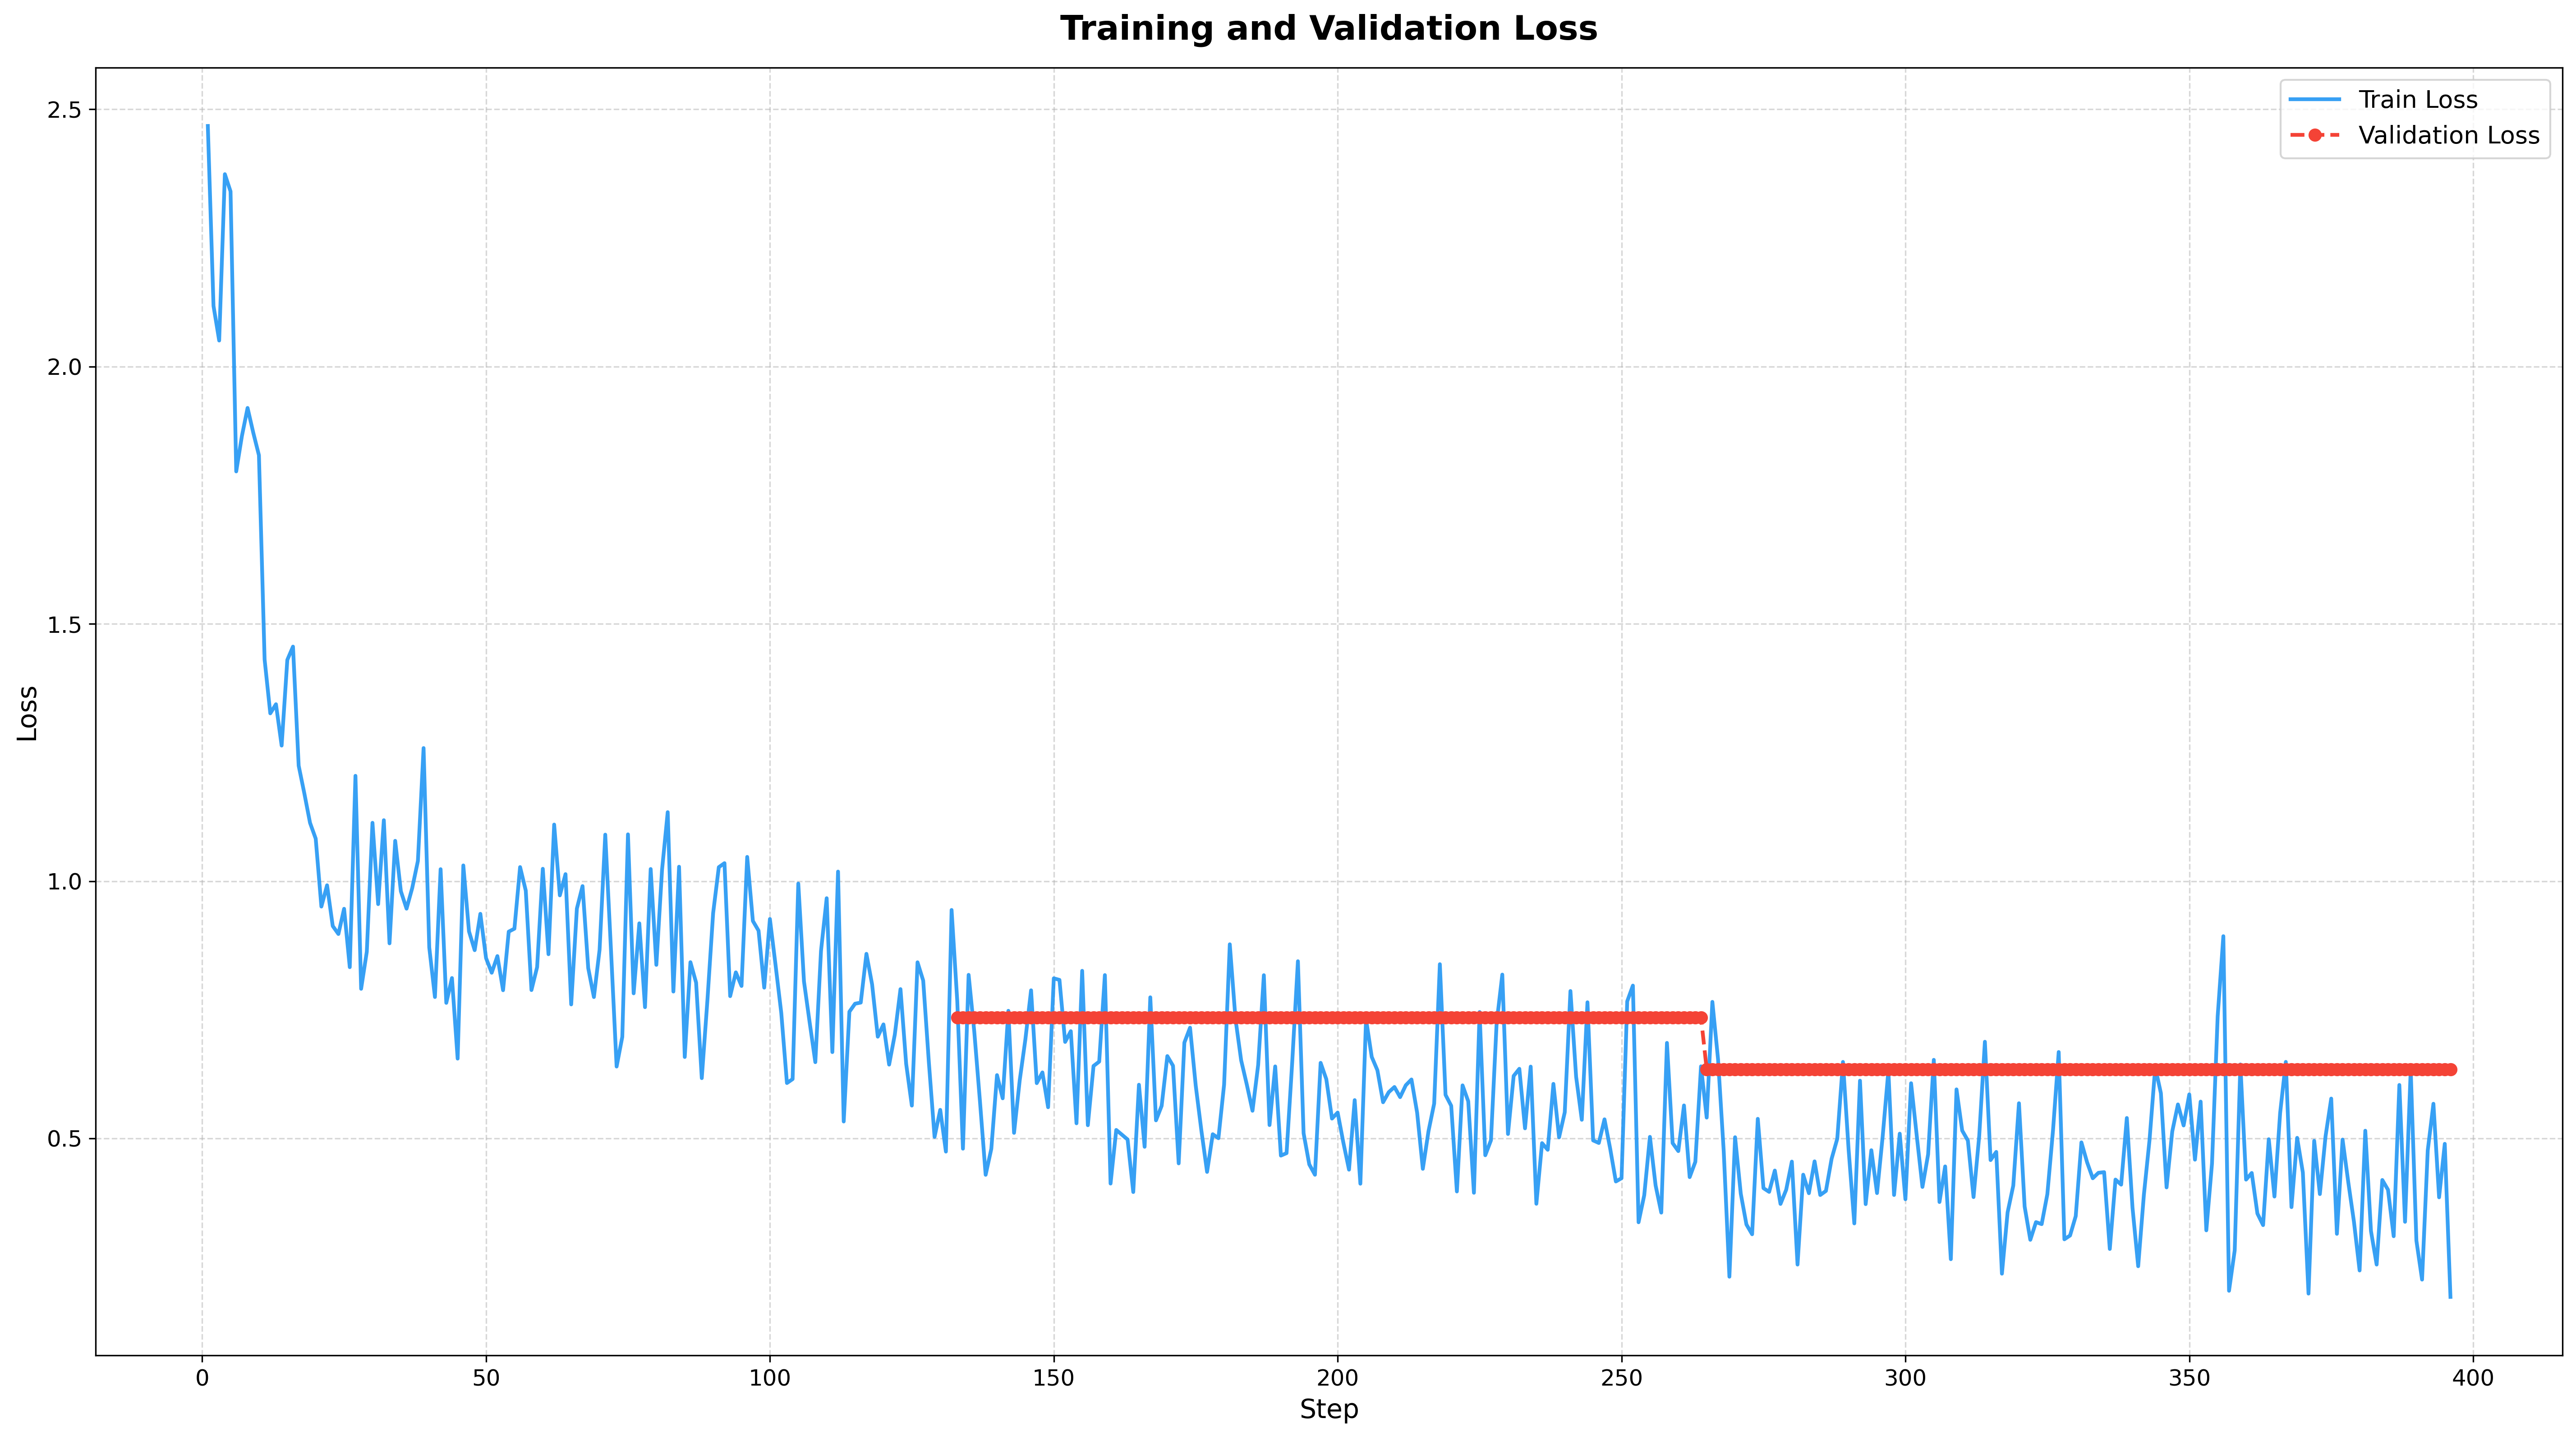


[GRAPH] accuracy_curve.png


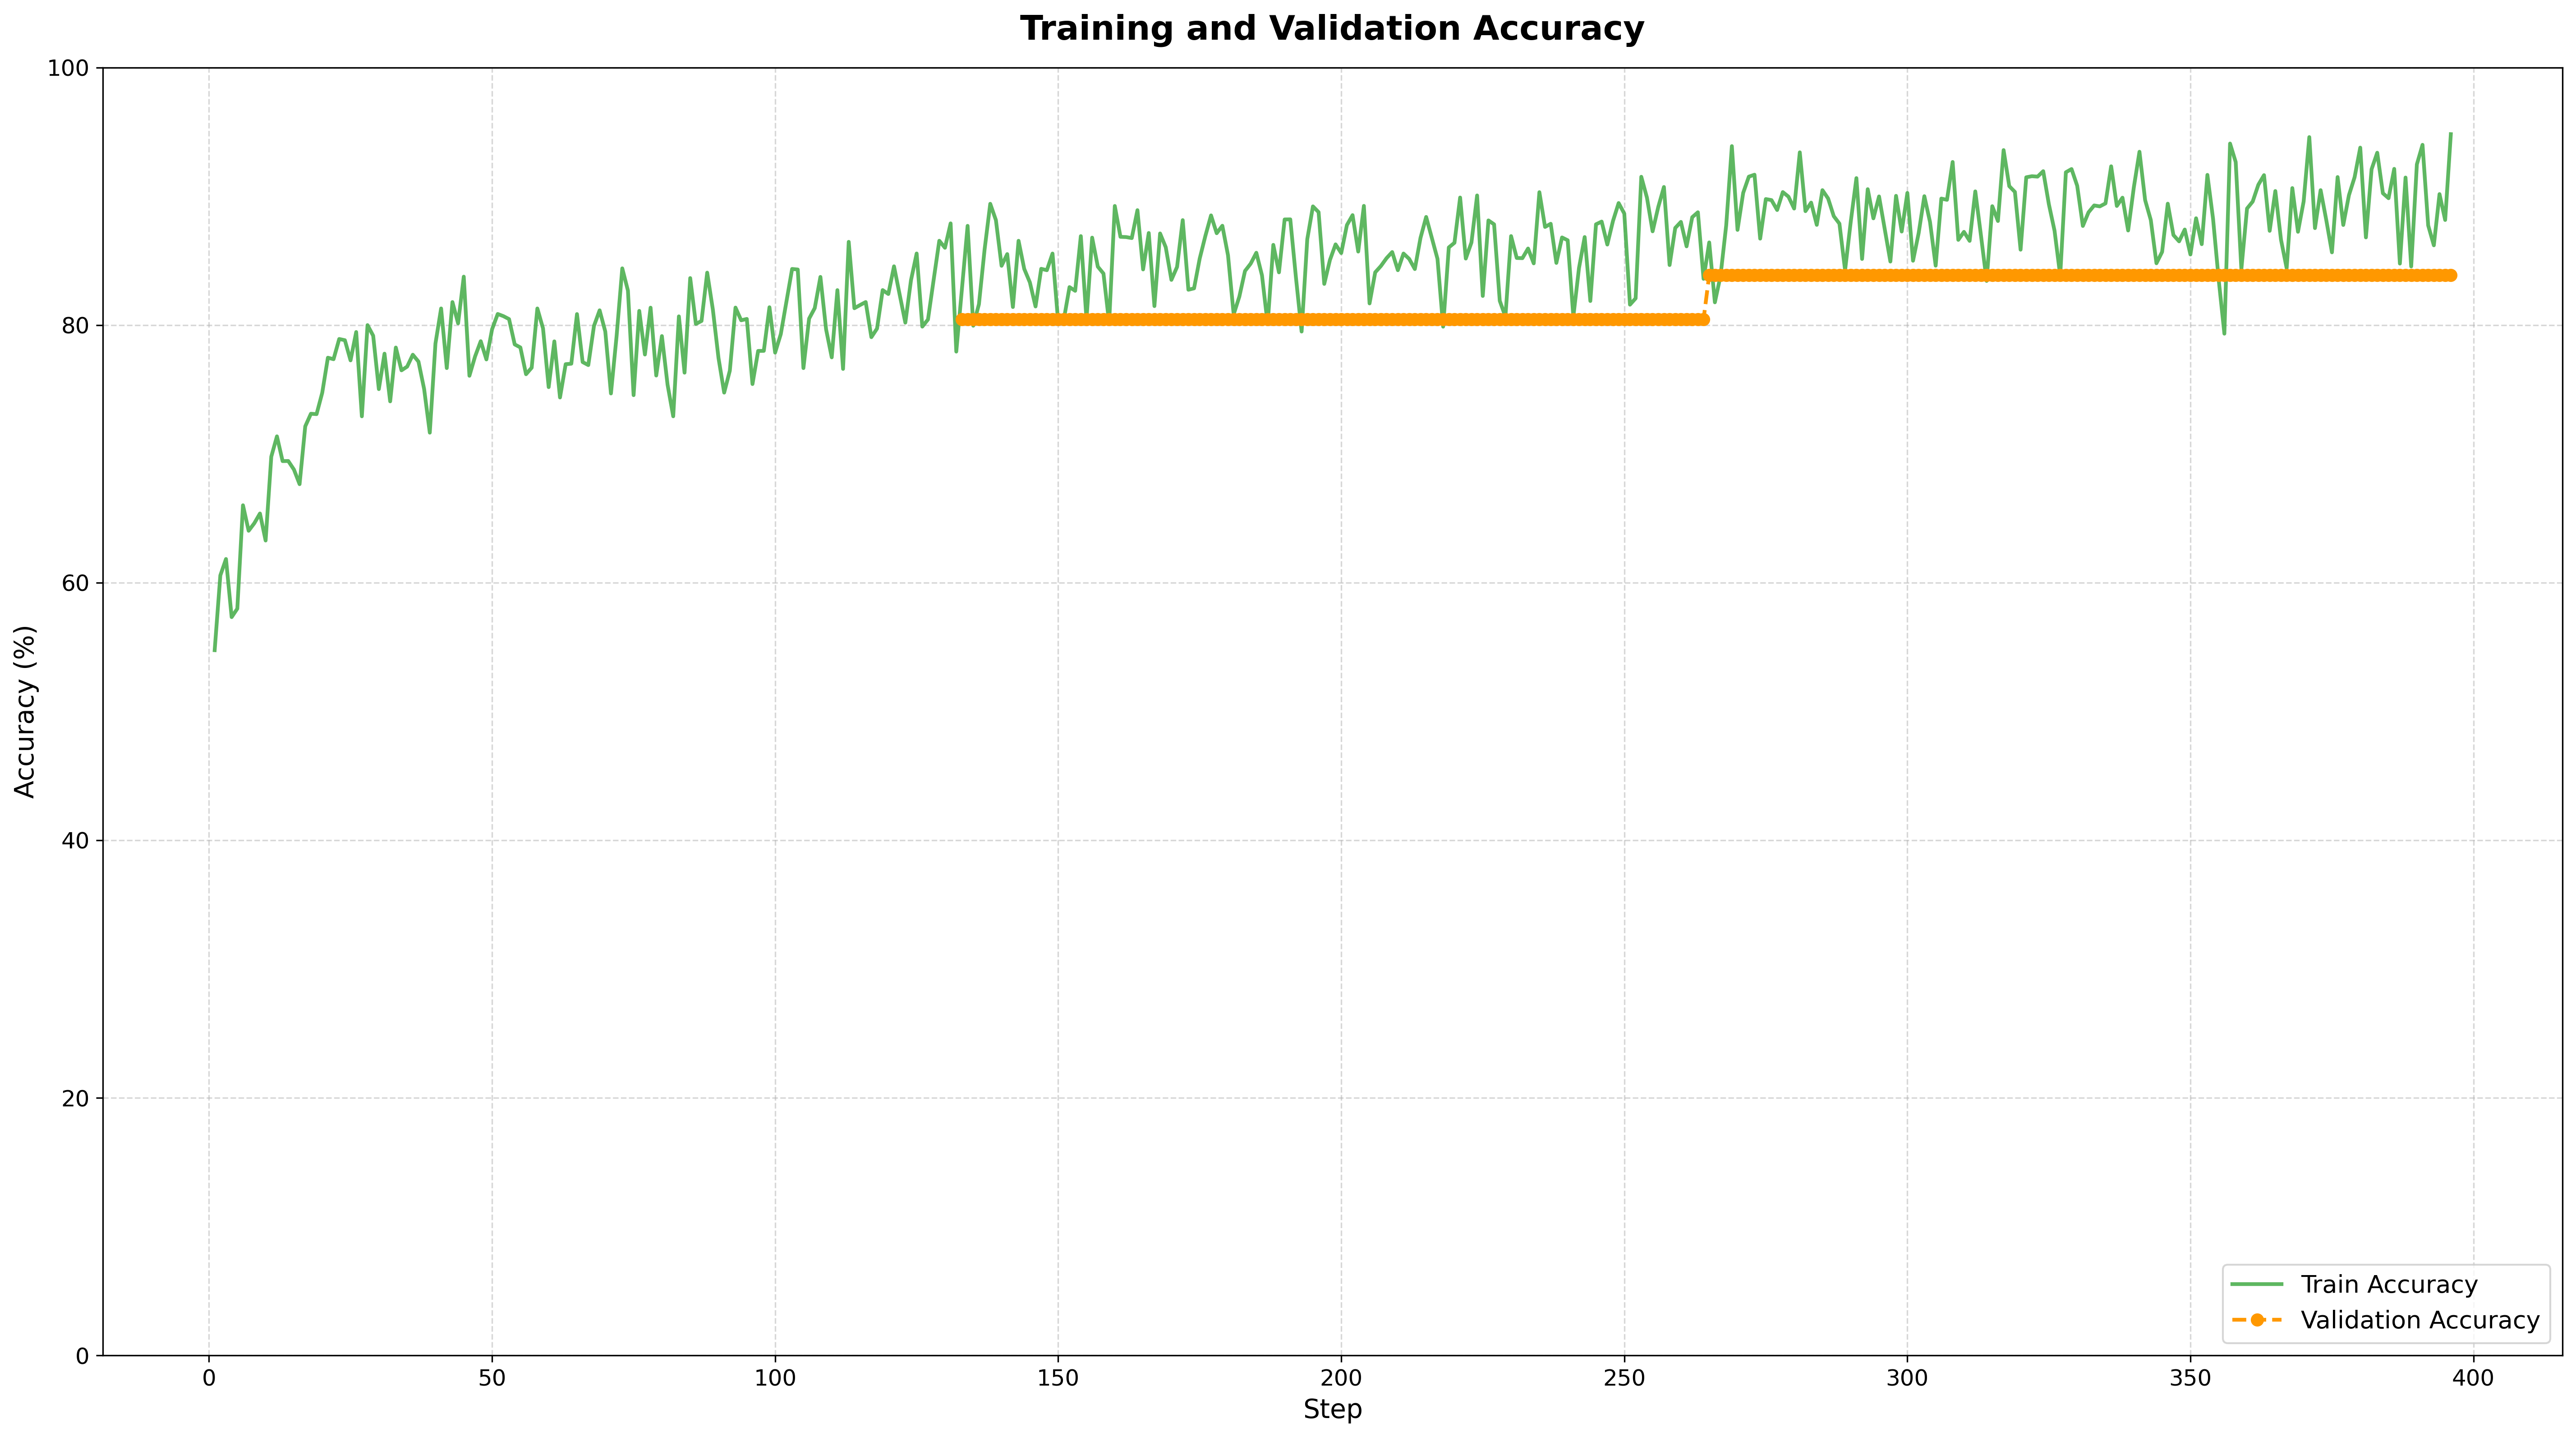

In [ ]:
# ── [셀 14] 10. 학습 로그 확인 ────────────────────────────────────────────────────────
import pandas as pd
import os

LOG_CSV = os.path.join(OUTPUT_DIR, 'training_logs.csv')

if os.path.exists(LOG_CSV):
    df_log = pd.read_csv(LOG_CSV)
    print(f'학습 로그: {len(df_log)} 행')
    print('\n[마지막 5행]')
    print(df_log.tail())
    print('\n[통계]')
    print(df_log[['train_loss', 'eval_loss', 'perplexity', 'eval_perplexity']].describe())

    # 학습 중 생성된 그래프 확인
    for fname in ['loss_curve.png', 'accuracy_curve.png']:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            from IPython.display import Image, display
            print(f'\n[GRAPH] {fname}')
            display(Image(fpath, width=900))
else:
    print(f'[WARN] 로그 없음: {LOG_CSV}')


---
## [셀 15] Phase 3 — Fine-tuned Model 평가

In [ ]:
# ── [셀 16] 11. Fine-tuned Model 평가 ────────────────────────────────────────────────
import gc
from peft import PeftModel

print('=' * 60)
print('[EVAL] Fine-tuned Model 평가 시작')
print('=' * 60)

dtype  = torch.bfloat16 if USE_BF16 else torch.float16
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if not os.path.isdir(LORA_DIR):
    raise FileNotFoundError(f'LoRA 어댑터 없음: {LORA_DIR}\ntrain.py가 완료되었는지 확인하세요.')

# Base 모델 (fp16, PEFT 로딩용)
print(f'[LOAD] Base model (fp16): {MODEL_ID}')
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=dtype,
)
ft_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    device_map={'': 0},
    attn_implementation=ATTN_IMPL,  # cell 5/6에서 결정 (flash_attention_2 or sdpa)
)

print(f'[LOAD] LoRA 어댑터 로드: {LORA_DIR}')
ft_model = PeftModel.from_pretrained(ft_base, LORA_DIR)
ft_model.config.use_cache = True

# 평가용 eval_ds 재사용 (위 셀에서 생성됨)
print('\n[EVAL] Fine-tuned model 추론 중...')
ft_results, ft_preds = evaluate_model_full(
    ft_model, tokenizer, UNITY_HOLDOUT,
    eval_dataset=eval_ds, device=device,
    eval_loss_samples=200,   # [FIX-1,2] 학습 eval과 동일 샘플 수
    max_length=MAX_LEN,      # [FIX-1] 학습 eval과 동일 max_length
)

print('\n[RESULT] Fine-tuned Model 평가 결과:')
for k, v in ft_results.items():
    if k != 'category_metrics':
        print(f'  {k:<25}: {v}')

del ft_model, ft_base
gc.collect()
torch.cuda.empty_cache()
print('\n[OK] Fine-tuned model 평가 완료, GPU 메모리 해제')


---
## [셀 17] Phase 4 — 모델 비교 & 결과 저장

In [ ]:
# ── [셀 18] 12. 비교 테이블 생성 ──────────────────────────────────────────────────────
import pandas as pd

def improvement_pct(base_val, ft_val, lower_is_better=False):
    """개선율 계산. lower_is_better=True이면 값이 낮을수록 개선"""
    if base_val is None or ft_val is None or base_val == 0:
        return None
    if lower_is_better:
        return round((base_val - ft_val) / base_val * 100, 2)
    else:
        return round((ft_val - base_val) / abs(base_val) * 100, 2)

METRICS_CONFIG = [
    ('loss',               'Loss',              True),
    ('perplexity',         'Perplexity (PPL)',   True),
    ('em',                 'Exact Match (EM)',   False),
    ('bleu',               'BLEU',              False),
    ('rouge_l',            'ROUGE-L',           False),
    ('codebleu',           'CodeBLEU',          False),
    ('avg_response_length','Avg Response Length',False),
    ('tokens_per_sec',     'Tokens/sec',        False),
]

rows = []
for key, label, lower_better in METRICS_CONFIG:
    bv = base_results.get(key)
    fv = ft_results.get(key)
    imp = improvement_pct(bv, fv, lower_better)
    imp_str = f'+{imp:.2f}%' if imp and imp > 0 else (f'{imp:.2f}%' if imp else 'N/A')
    rows.append({
        'Metric':           label,
        'Base Model':       bv,
        'Fine-tuned Model': fv,
        'Improvement':      imp_str,
    })

df_compare = pd.DataFrame(rows)

print('\n' + '=' * 70)
print('  Base Model vs Fine-tuned Model 비교')
print('=' * 70)
print(df_compare.to_string(index=False))
print('=' * 70)

# 카테고리별 BLEU 비교
print('\n[카테고리별 BLEU 비교]')
for cat in ['unity_api', 'csharp_codegen', 'bug_resolution', 'system_design', 'optimization']:
    b_bleu = base_results.get('category_metrics', {}).get(cat, {}).get('bleu', None)
    f_bleu = ft_results.get('category_metrics', {}).get(cat, {}).get('bleu', None)
    imp = improvement_pct(b_bleu, f_bleu, False)
    imp_str = f'+{imp:.2f}%' if imp and imp > 0 else (f'{imp:.2f}%' if imp else 'N/A')
    print(f'  {cat:<22}: Base={b_bleu}  FT={f_bleu}  ({imp_str})')



  Base Model vs Fine-tuned Model 비교
             Metric  Base Model  Fine-tuned Model Improvement
               Loss      2.3745            0.2187     +90.79%
   Perplexity (PPL)     10.7456            1.2445     +88.42%
   Exact Match (EM)      0.0000            0.0000         N/A
               BLEU      5.0431           10.7491    +113.14%
            ROUGE-L      0.1325            0.2142     +61.66%
           CodeBLEU         NaN               NaN         N/A
Avg Response Length    256.0000          131.8000     -48.52%
         Tokens/sec     12.2600            6.8400     -44.21%

[카테고리별 BLEU 비교]
  unity_api             : Base=4.0171  FT=23.7716  (+491.76%)
  csharp_codegen        : Base=11.6287  FT=17.5521  (+50.94%)
  bug_resolution        : Base=2.6142  FT=0.7104  (-72.83%)
  system_design         : Base=6.015  FT=7.5085  (+24.83%)
  optimization          : Base=0.4849  FT=0.7125  (+46.94%)


[SAVE] /content/unity-lm/evaluation/loss_curve.png
[SAVE] /content/unity-lm/evaluation/lr_curve.png
[SAVE] /content/unity-lm/evaluation/model_comparison.png
[SAVE] /content/unity-lm/evaluation/improvement_chart.png


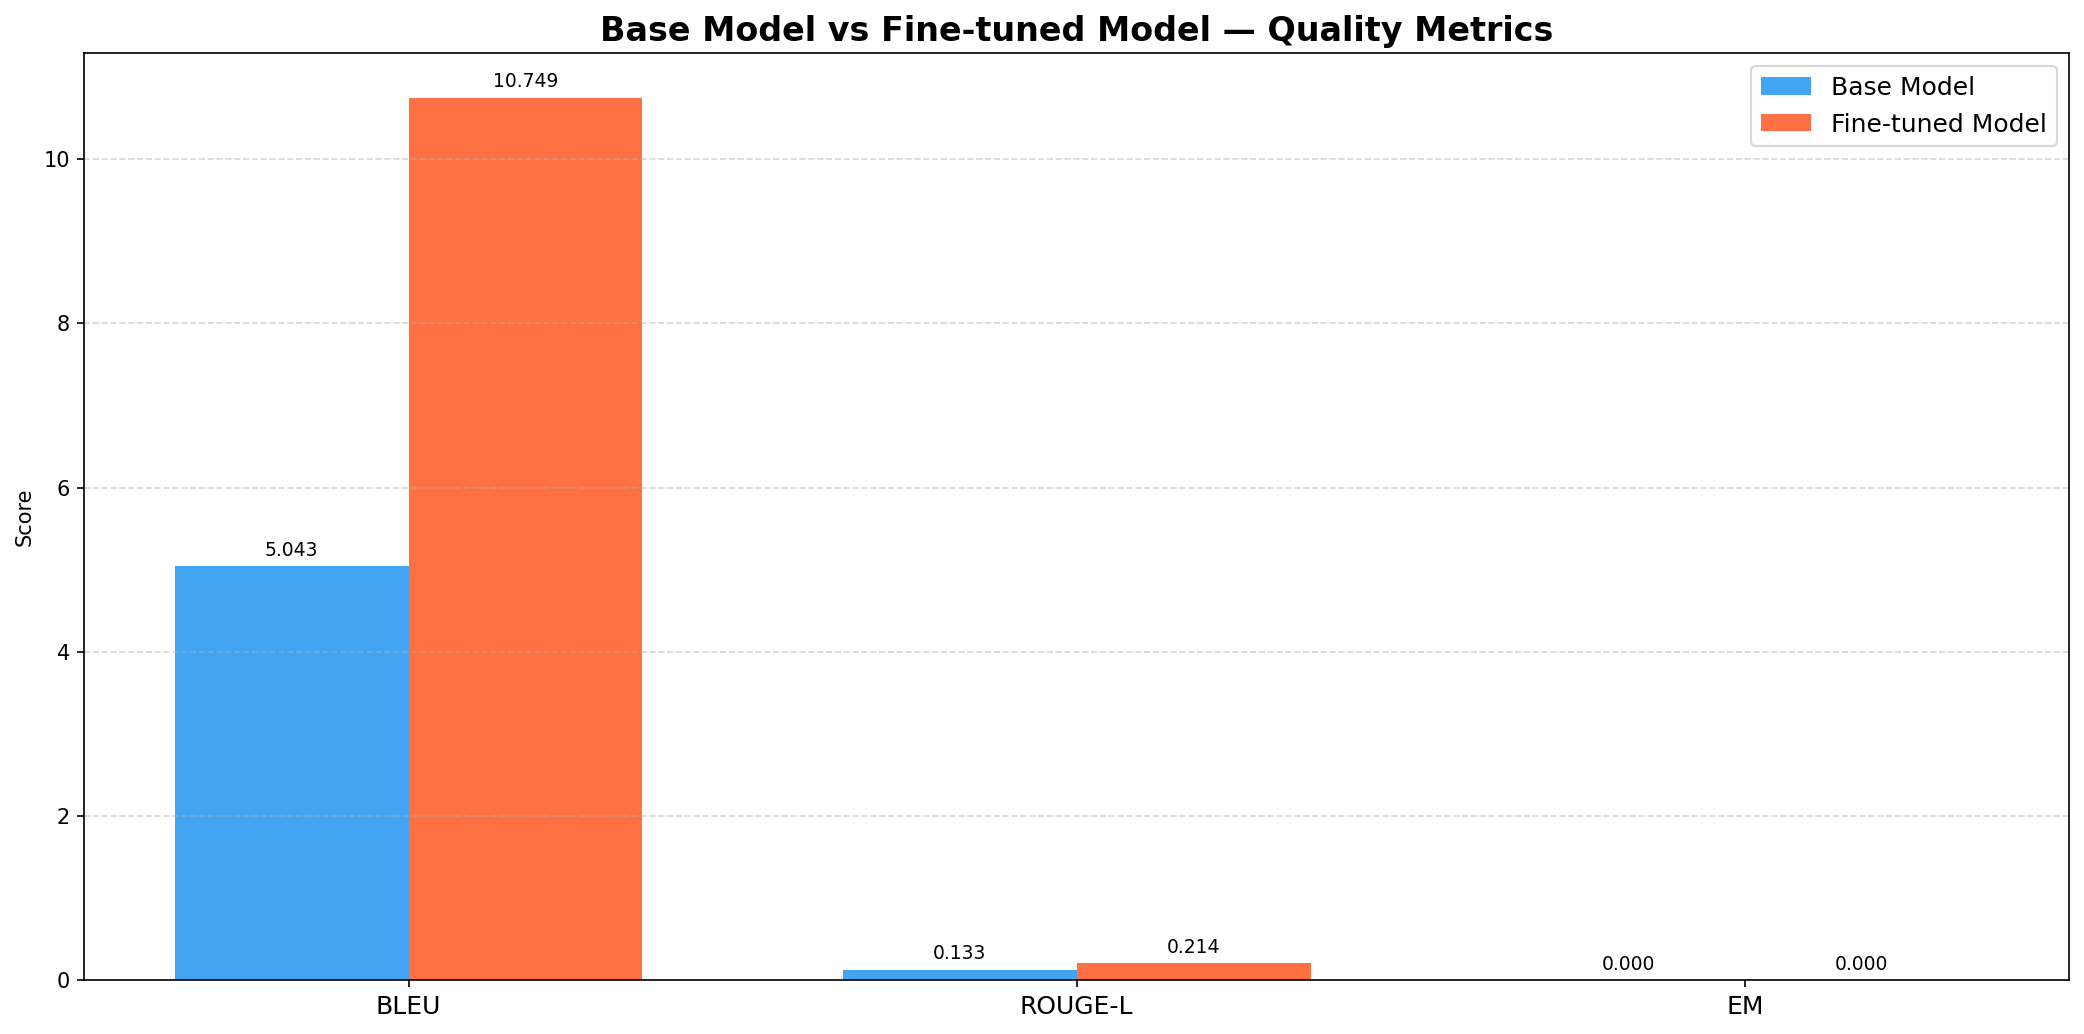

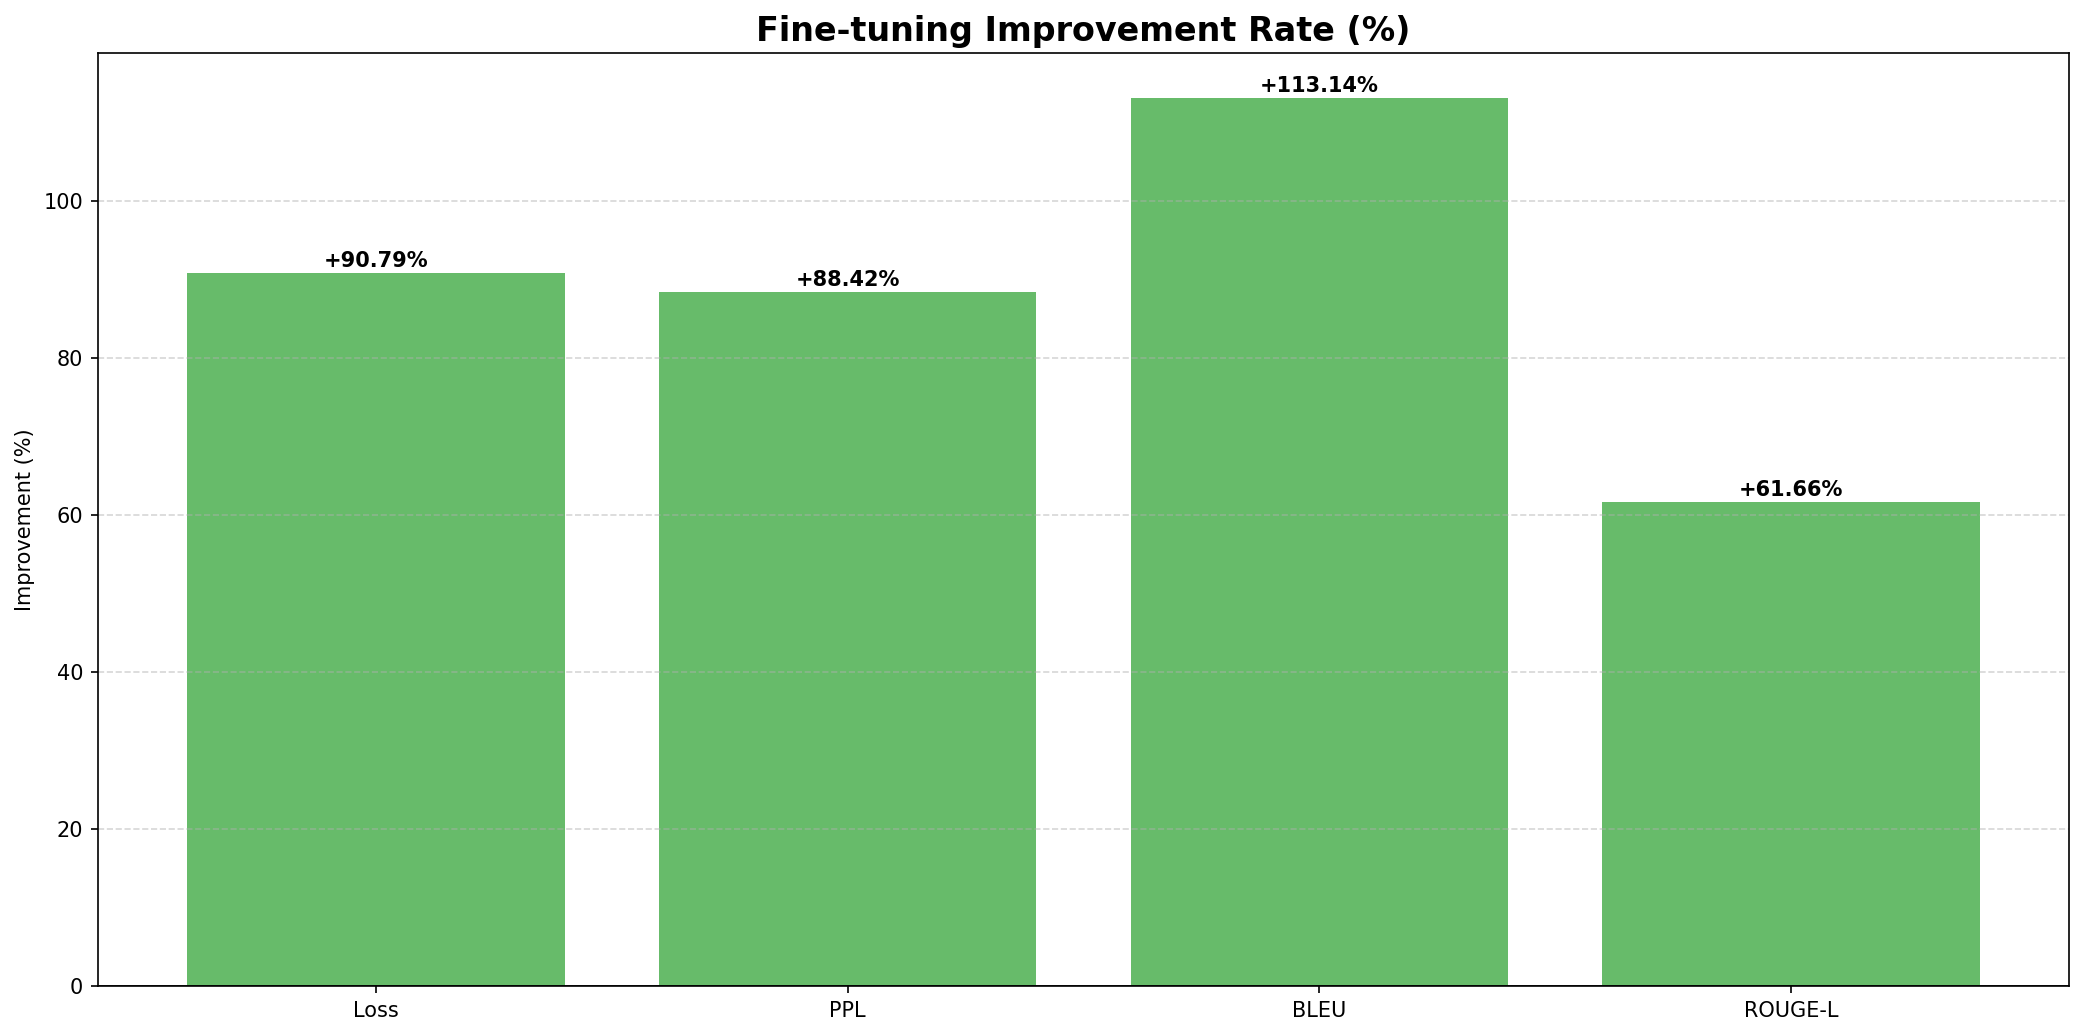

In [ ]:
# ── [셀 19] 13. 그래프 생성 ───────────────────────────────────────────────────────────
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import os

os.makedirs(EVAL_DIR, exist_ok=True)

STYLE = {
    'base_color':  '#2196F3',
    'ft_color':    '#FF5722',
    'imp_color':   '#4CAF50',
    'lr_color':    '#9C27B0',
    'fig_size':    (14, 7),
    'dpi':         150,
}

# ── 그래프 1: Loss Curve ───────────────────────────────────────────────────
LOG_CSV = os.path.join(OUTPUT_DIR, 'training_logs.csv')
if os.path.exists(LOG_CSV):
    df_log = pd.read_csv(LOG_CSV)
    fig, ax = plt.subplots(figsize=STYLE['fig_size'])
    mask_tl = df_log['train_loss'].notna()
    mask_el = df_log['eval_loss'].notna()
    if mask_tl.any():
        ax.plot(df_log.loc[mask_tl, 'step'], df_log.loc[mask_tl, 'train_loss'],
                label='Train Loss', color=STYLE['base_color'], linewidth=2, alpha=0.9)
    if mask_el.any():
        ax.plot(df_log.loc[mask_el, 'step'], df_log.loc[mask_el, 'eval_loss'],
                label='Eval Loss', color=STYLE['ft_color'], linewidth=2,
                linestyle='--', marker='o', markersize=6)
    ax.set_title('Training & Validation Loss Curve', fontsize=16, fontweight='bold')
    ax.set_xlabel('Step'); ax.set_ylabel('Loss')
    ax.legend(fontsize=12); ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    loss_path = os.path.join(EVAL_DIR, 'loss_curve.png')
    fig.savefig(loss_path, dpi=STYLE['dpi'], bbox_inches='tight')
    plt.close(fig)
    print(f'[SAVE] {loss_path}')

    # ── 그래프 2: Learning Rate Curve ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=STYLE['fig_size'])
    mask_lr = df_log['learning_rate'].notna() & (df_log['learning_rate'] != '')
    if mask_lr.any():
        lr_vals = pd.to_numeric(df_log.loc[mask_lr, 'learning_rate'], errors='coerce')
        ax.plot(df_log.loc[mask_lr, 'step'], lr_vals,
                color=STYLE['lr_color'], linewidth=2)
    ax.set_title('Learning Rate Schedule', fontsize=16, fontweight='bold')
    ax.set_xlabel('Step'); ax.set_ylabel('Learning Rate')
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    lr_path = os.path.join(EVAL_DIR, 'lr_curve.png')
    fig.savefig(lr_path, dpi=STYLE['dpi'], bbox_inches='tight')
    plt.close(fig)
    print(f'[SAVE] {lr_path}')
else:
    print(f'[WARN] training_logs.csv 없음 — Loss/LR 그래프 건너뜀')

# ── 그래프 3: Base vs Fine-tuned 비교 막대그래프 ─────────────────────────
COMPARE_METRICS = [
    ('bleu',    'BLEU',     False),
    ('rouge_l', 'ROUGE-L',  False),
    ('em',      'EM',       False),
]
if HAS_CODEBLEU and base_results.get('codebleu') is not None:
    COMPARE_METRICS.append(('codebleu', 'CodeBLEU', False))

labels  = [m[1] for m in COMPARE_METRICS]
base_v  = [base_results.get(m[0]) or 0 for m in COMPARE_METRICS]
ft_v    = [ft_results.get(m[0]) or 0 for m in COMPARE_METRICS]

x      = np.arange(len(labels))
width  = 0.35
fig, ax = plt.subplots(figsize=STYLE['fig_size'])
bars1 = ax.bar(x - width/2, base_v, width, label='Base Model',      color=STYLE['base_color'], alpha=0.85)
bars2 = ax.bar(x + width/2, ft_v,   width, label='Fine-tuned Model', color=STYLE['ft_color'],  alpha=0.85)

for bar in (*bars1, *bars2):
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

ax.set_title('Base Model vs Fine-tuned Model — Quality Metrics', fontsize=16, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Score'); ax.legend(fontsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
comp_path = os.path.join(EVAL_DIR, 'model_comparison.png')
fig.savefig(comp_path, dpi=STYLE['dpi'], bbox_inches='tight')
plt.close(fig)
print(f'[SAVE] {comp_path}')

# ── 그래프 4: 개선율 차트 ────────────────────────────────────────────────
IMP_METRICS = [
    ('loss',      'Loss',     True),
    ('perplexity','PPL',      True),
    ('bleu',      'BLEU',     False),
    ('rouge_l',   'ROUGE-L',  False),
    ('em',        'EM',       False),
]
if HAS_CODEBLEU and base_results.get('codebleu') is not None:
    IMP_METRICS.append(('codebleu', 'CodeBLEU', False))

imp_labels, imp_vals, imp_colors = [], [], []
for key, label, lower_better in IMP_METRICS:
    bv = base_results.get(key)
    fv = ft_results.get(key)
    imp = improvement_pct(bv, fv, lower_better)
    if imp is not None:
        imp_labels.append(label)
        imp_vals.append(imp)
        imp_colors.append('#4CAF50' if imp >= 0 else '#F44336')

fig, ax = plt.subplots(figsize=STYLE['fig_size'])
bars = ax.bar(imp_labels, imp_vals, color=imp_colors, alpha=0.85)
for bar, val in zip(bars, imp_vals):
    ax.annotate(f'{val:+.2f}%',
                xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 3 if val >= 0 else -12), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Fine-tuning Improvement Rate (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Improvement (%)')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
imp_path = os.path.join(EVAL_DIR, 'improvement_chart.png')
fig.savefig(imp_path, dpi=STYLE['dpi'], bbox_inches='tight')
plt.close(fig)
print(f'[SAVE] {imp_path}')

# Colab에서 그래프 미리보기
from IPython.display import Image, display
for path in [comp_path, imp_path]:
    if os.path.exists(path):
        display(Image(path, width=900))


In [ ]:
# ── [셀 20] 14. 결과 파일 저장 (CSV / JSON / Markdown) ────────────────────────────────
import csv, json, os, datetime

os.makedirs(EVAL_DIR, exist_ok=True)

# ── metrics.csv ──────────────────────────────────────────────────────────
csv_path = os.path.join(EVAL_DIR, 'metrics.csv')
fields = ['metric', 'base_model', 'finetuned_model', 'improvement']
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    for row in rows:  # df_compare rows
        writer.writerow({
            'metric':          row['Metric'],
            'base_model':      row['Base Model'],
            'finetuned_model': row['Fine-tuned Model'],
            'improvement':     row['Improvement'],
        })
print(f'[SAVE] {csv_path}')

# ── metrics.json ─────────────────────────────────────────────────────────
json_path = os.path.join(EVAL_DIR, 'metrics.json')
payload = {
    'timestamp':       datetime.datetime.now().isoformat(),
    'base_model_id':   MODEL_ID,
    'lora_adapter':    LORA_DIR,
    'base_metrics':    {k: v for k, v in base_results.items() if k != 'category_metrics'},
    'ft_metrics':      {k: v for k, v in ft_results.items()   if k != 'category_metrics'},
    'base_category':   base_results.get('category_metrics', {}),
    'ft_category':     ft_results.get('category_metrics', {}),
    'comparison':      [
        {
            'metric':     r['Metric'],
            'base':       r['Base Model'],
            'finetuned':  r['Fine-tuned Model'],
            'improvement':r['Improvement'],
        }
        for r in rows
    ],
}
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)
print(f'[SAVE] {json_path}')

# ── report.md ────────────────────────────────────────────────────────────
md_path = os.path.join(EVAL_DIR, 'report.md')
now_str = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

md_lines = [
    '# Unity Assistant Fine-tuning Evaluation Report\n',
    f'**Generated**: {now_str}\n\n',
    f'**Base Model**: `{MODEL_ID}`\n\n',
    f'**Fine-tuned**: `{LORA_DIR}`\n\n',
    '---\n\n',
    '## Overall Metrics Comparison\n\n',
    '| Metric | Base Model | Fine-tuned Model | Improvement |\n',
    '|--------|-----------|-----------------|-------------|\n',
]
for row in rows:
    bv = row['Base Model']
    fv = row['Fine-tuned Model']
    md_lines.append(f"| {row['Metric']:<22} | {str(bv):<12} | {str(fv):<16} | {row['Improvement']:<12} |\n")

md_lines += [
    '\n---\n\n',
    '## Unity Holdout Category Performance (BLEU)\n\n',
    '| Category | Base Model | Fine-tuned Model | Improvement |\n',
    '|----------|-----------|-----------------|-------------|\n',
]
for cat in ['unity_api', 'csharp_codegen', 'bug_resolution', 'system_design', 'optimization']:
    b_bleu = base_results.get('category_metrics', {}).get(cat, {}).get('bleu', 'N/A')
    f_bleu = ft_results.get('category_metrics', {}).get(cat, {}).get('bleu', 'N/A')
    imp = improvement_pct(b_bleu if b_bleu != 'N/A' else None,
                          f_bleu if f_bleu != 'N/A' else None, False)
    imp_s = f'+{imp:.2f}%' if imp and imp > 0 else (f'{imp:.2f}%' if imp else 'N/A')
    md_lines.append(f'| {cat:<20} | {str(b_bleu):<12} | {str(f_bleu):<16} | {imp_s:<12} |\n')

md_lines += [
    '\n---\n\n',
    '## Graphs\n\n',
    '| Chart | File |\n',
    '|-------|------|\n',
    '| Loss Curve         | `loss_curve.png`       |\n',
    '| LR Curve           | `lr_curve.png`         |\n',
    '| Model Comparison   | `model_comparison.png` |\n',
    '| Improvement Chart  | `improvement_chart.png`|\n',
]

with open(md_path, 'w', encoding='utf-8') as f:
    f.writelines(md_lines)
print(f'[SAVE] {md_path}')

print('\n[OK] 평가 결과 저장 완료')
print(f'  {EVAL_DIR}/')
for fname in ['metrics.csv', 'metrics.json', 'report.md',
              'loss_curve.png', 'lr_curve.png',
              'model_comparison.png', 'improvement_chart.png']:
    fpath = os.path.join(EVAL_DIR, fname)
    size  = os.path.getsize(fpath) if os.path.exists(fpath) else 0
    tick  = '✓' if os.path.exists(fpath) else '✗'
    print(f'  [{tick}] {fname:<28} {size:>8} bytes')


[SAVE] /content/unity-lm/evaluation/metrics.csv
[SAVE] /content/unity-lm/evaluation/metrics.json
[SAVE] /content/unity-lm/evaluation/report.md

[OK] 평가 결과 저장 완료
  /content/unity-lm/evaluation/
  [✓] metrics.csv                       295 bytes
  [✓] metrics.json                     2788 bytes
  [✓] report.md                        1730 bytes
  [✓] loss_curve.png                 170570 bytes
  [✓] lr_curve.png                    95066 bytes
  [✓] model_comparison.png            49886 bytes
  [✓] improvement_chart.png           48827 bytes


---
## [셀 21] Phase 5 — GGUF 변환 & 양자화

LoRA 어댑터를 FP16으로 머지한 후 GGUF Q4_K_M으로 변환합니다.

In [ ]:
# ── [셀 22] 15. llama.cpp 빌드 (CUDA 지원) ───────────────────────────────────────────
import subprocess, os

LLAMA_SRC = f'{PROJECT_DIR}/llama.cpp-src'

if not os.path.isdir(LLAMA_SRC):
    print('[BUILD] llama.cpp 클론 중...')
    subprocess.run(
        ['git', 'clone', '--depth=1',
         'https://github.com/ggml-org/llama.cpp', LLAMA_SRC],
        check=True
    )
else:
    print(f'[SKIP] 이미 존재: {LLAMA_SRC}')

# 의존성
!pip install -q gguf numpy

# CUDA 빌드 (A100 GPU 가속 — llama-quantize 및 llama-cli GPU 추론 사용)
BUILD_DIR = f'{LLAMA_SRC}/build'
if not os.path.exists(f'{BUILD_DIR}/bin/llama-quantize'):
    print('[BUILD] cmake 빌드 중 (CPU)...')
    os.makedirs(BUILD_DIR, exist_ok=True)
    subprocess.run(['cmake', '..', '-DGGML_CUDA=ON'], cwd=BUILD_DIR, check=True)
    subprocess.run(['cmake', '--build', '.', '--config', 'Release', '-j4'],
                   cwd=BUILD_DIR, check=True)
    print('[OK] 빌드 완료')
else:
    print('[SKIP] 이미 빌드됨')

QUANTIZE_BIN   = f'{BUILD_DIR}/bin/llama-quantize'
CONVERT_SCRIPT = f'{LLAMA_SRC}/convert_hf_to_gguf.py'
print(f'\nconvert_hf_to_gguf.py : {CONVERT_SCRIPT}')
print(f'llama-quantize        : {QUANTIZE_BIN}')


[BUILD] llama.cpp 클론 중...
[BUILD] cmake 빌드 중 (CPU)...


In [ ]:
# ── [셀 23] 16. LoRA 머지 (FP16 HuggingFace 모델) ────────────────────────────────────
import subprocess, sys, os

MERGE_SCRIPT = os.path.join(PROJECT_DIR, 'merge_lora.py')

if os.path.isdir(MERGED_DIR) and len(os.listdir(MERGED_DIR)) > 2:
    print(f'[SKIP] 이미 머지된 모델 존재: {MERGED_DIR}')
else:
    print(f'[MERGE] LoRA 머지 시작: {LORA_DIR} → {MERGED_DIR}')
    result = subprocess.run(
        [
            sys.executable, MERGE_SCRIPT,
            '--base',    MODEL_ID,
            '--adapter', LORA_DIR,
            '--out',     MERGED_DIR,
        ],
        cwd=PROJECT_DIR,
        capture_output=False,
    )
    if result.returncode == 0:
        print(f'[OK] 머지 완료: {MERGED_DIR}')
    else:
        raise RuntimeError('merge_lora.py 실패')

# 크기 확인
if os.path.isdir(MERGED_DIR):
    total = sum(
        os.path.getsize(os.path.join(MERGED_DIR, f))
        for f in os.listdir(MERGED_DIR)
        if os.path.isfile(os.path.join(MERGED_DIR, f))
    )
    print(f'Merged model 크기: {total / 1e9:.2f} GB')


In [ ]:
# ── [셀 24] 17. HuggingFace → F16 GGUF 변환 ─────────────────────────────────────────
import subprocess, sys, os

F16_GGUF = os.path.join(GGUF_DIR, 'qwen-unity.gguf')

if os.path.exists(F16_GGUF):
    size_gb = os.path.getsize(F16_GGUF) / 1e9
    print(f'[SKIP] F16 GGUF 이미 존재: {F16_GGUF} ({size_gb:.2f}GB)')
else:
    print(f'[CONVERT] {MERGED_DIR} → {F16_GGUF}')
    result = subprocess.run(
        [
            sys.executable, CONVERT_SCRIPT,
            MERGED_DIR,
            '--outfile', F16_GGUF,
            '--outtype', 'f16',
        ],
        capture_output=False,
    )
    if result.returncode == 0:
        size_gb = os.path.getsize(F16_GGUF) / 1e9
        print(f'[OK] F16 GGUF: {F16_GGUF} ({size_gb:.2f}GB)')
    else:
        raise RuntimeError('GGUF 변환 실패')


In [ ]:
# ── [셀 25] 18. GGUF 양자화 (Q4_K_M 우선, 추가 형식 선택) ────────────────────────────
import subprocess, os

QUANT_TYPES = ['Q4_K_M', 'Q4_K_S', 'IQ4_XS']
quant_results = {}

for qtype in QUANT_TYPES:
    out_path = os.path.join(GGUF_DIR, f'qwen-unity-{qtype.lower()}.gguf')

    if os.path.exists(out_path):
        size_gb = os.path.getsize(out_path) / 1e9
        print(f'[SKIP] {qtype}: {out_path} ({size_gb:.2f}GB)')
        quant_results[qtype] = out_path
        continue

    print(f'[QUANT] {qtype} 양자화 중...')
    result = subprocess.run(
        [QUANTIZE_BIN, F16_GGUF, out_path, qtype],
        capture_output=False,
    )
    if result.returncode == 0:
        size_gb = os.path.getsize(out_path) / 1e9
        print(f'[OK] {qtype}: {out_path} ({size_gb:.2f}GB)')
        quant_results[qtype] = out_path
    else:
        print(f'[ERROR] {qtype} 양자화 실패')

print('\n[요약] 생성된 GGUF 파일:')
for qtype, path in quant_results.items():
    if os.path.exists(path):
        sz = os.path.getsize(path) / 1e9
        print(f'  {qtype:<10}: {sz:.2f}GB  {path}')


In [ ]:
# ── [셀 26] [FIX-4] Q4_K_M GGUF PPL & 추론 속도 평가 ────────────────────────────────
# 실배포(GGUF Q4_K_M, GTX 1060 3GB)와 동일한 조건으로 PPL / 속도를 측정합니다.
# llama-perplexity : PPL 측정 (eval_ds 50샘플 텍스트 파일 사용)
# llama-cli        : CPU 추론 속도 측정
# ── [셀 26] [FIX-5] Q4_K_M GGUF PPL & 추론 속도 평가 ────────────────────────────────
# 실배포(GGUF Q4_K_M) 속도/품질 측정. CUDA 빌드면 GPU(-ngl 99), 아니면 CPU 폴백.
import subprocess, os, time, glob, re, json as _json

LLAMA_PPL_BIN = f'{BUILD_DIR}/bin/llama-perplexity'
LLAMA_CLI_BIN = f'{BUILD_DIR}/bin/llama-cli'
Q4KM_PATH = quant_results.get('Q4_K_M', '')

gguf_ppl = None
gguf_tps = None

# ── 0) CUDA 빌드 여부 진단 ───────────────────────────────────────────────
cuda_libs = glob.glob(f'{BUILD_DIR}/**/*ggml-cuda*', recursive=True) \
          + glob.glob(f'{BUILD_DIR}/**/*libggml-cuda*', recursive=True)
HAS_CUDA = len(cuda_libs) > 0
NGL = '99' if HAS_CUDA else '0'
print(f'[빌드] CUDA 백엔드: {"감지됨 → GPU 가속" if HAS_CUDA else "없음 → CPU 폴백(느림)"}')
if not HAS_CUDA:
    print('       ⚠️ CPU 전용 빌드입니다. GPU로 측정하려면 셀 22의')
    print('          build 디렉터리를 지우고 -DGGML_CUDA=ON 으로 재빌드하세요:')
    print(f'          !rm -rf {BUILD_DIR}  # 후 셀 22 재실행')


def _parse_tps(text):
    """llama.cpp가 stderr에 찍는 'N tokens per second'를 파싱."""
    m = re.findall(r'([\d.]+)\s*tokens per second', text)
    return round(float(m[-1]), 1) if m else None


if not Q4KM_PATH or not os.path.exists(Q4KM_PATH):
    print('[SKIP] Q4_K_M GGUF 없음 — quantize 셀을 먼저 실행하세요')
else:
    # ── 1) 추론 속도 측정 ─────────────────────────────────────────────────
    TEST_PROMPT = (
        '<|im_start|>user\n'
        'How do I use Rigidbody.AddForce to move a player in Unity?\n'
        '<|im_end|>\n<|im_start|>assistant\n'
    )
    if os.path.exists(LLAMA_CLI_BIN):
        n_predict = '128' if HAS_CUDA else '64'   # CPU면 토큰 수 축소
        timeout_s = 120 if HAS_CUDA else 300       # CPU면 여유 있게
        print(f'[GGUF] 추론 속도 측정 중 (-ngl {NGL}, -n {n_predict})...')
        try:
            r = subprocess.run(
                [LLAMA_CLI_BIN, '-m', Q4KM_PATH,
                 '-ngl', NGL, '-c', '2048', '-n', n_predict,
                 '-t', str(os.cpu_count() or 4),
                 '--temp', '0.1', '--repeat-penalty', '1.1',
                 '-no-cnv', '-p', TEST_PROMPT, '--no-display-prompt'],
                capture_output=True, text=True, timeout=timeout_s,
                stdin=subprocess.DEVNULL,
            )
            if r.returncode == 0:
                # llama.cpp 자체 perf 출력(stderr)에서 정확한 tok/s 파싱
                gguf_tps = _parse_tps(r.stderr) or _parse_tps(r.stdout)
                if gguf_tps:
                    print(f'[GGUF] 추론 속도: ~{gguf_tps} tokens/sec')
                else:
                    print('[GGUF][WARN] tok/s 파싱 실패 — stderr 끝:')
                    print(r.stderr[-400:])
            else:
                print(f'[GGUF][WARN] 속도 측정 실패:\n{r.stderr[-400:]}')
        except subprocess.TimeoutExpired:
            print(f'[GGUF][WARN] {timeout_s}s 타임아웃 — 속도 측정 건너뜀.')
            print('       CUDA 빌드가 아니거나 GPU 런타임이 미연결일 수 있습니다.')
    else:
        print(f'[SKIP] llama-cli 없음: {LLAMA_CLI_BIN}')

    # ── 2) PPL 측정 (eval_ds 50 샘플) ────────────────────────────────────────
    ppl_texts = []
    for sample in list(eval_ds)[:50]:
        msgs = sample.get('messages') or []
        if msgs:
            t = tokenizer.apply_chat_template(
                msgs, tokenize=False, add_generation_prompt=False)
            ppl_texts.append(t)

    ppl_txt_path = os.path.join(EVAL_DIR, 'gguf_eval.txt')
    with open(ppl_txt_path, 'w', encoding='utf-8') as f:
        f.write('\n\n'.join(ppl_texts))

    if os.path.exists(LLAMA_PPL_BIN):
        print('[GGUF] PPL 측정 중 (3~5분)...')
        try:
            r = subprocess.run(
                [LLAMA_PPL_BIN, '-m', Q4KM_PATH,
                 '-ngl', NGL, '--file', ppl_txt_path,
                 '-c', '512', '--ppl-stride', '256', '--no-mmap'],
                capture_output=True, text=True, timeout=900,
                stdin=subprocess.DEVNULL,
            )
            for line in (r.stdout + r.stderr).split('\n'):
                if 'Final estimate' in line and 'PPL' in line:
                    try:
                        gguf_ppl = float(line.split('=')[1].strip().split()[0])
                        print(f'[GGUF] Q4_K_M PPL: {gguf_ppl:.4f}')
                    except Exception:
                        pass
            if gguf_ppl is None:
                print(f'[GGUF][WARN] PPL 파싱 실패 — 출력 끝:\n{r.stderr[-400:]}')
        except subprocess.TimeoutExpired:
            print('[GGUF][WARN] PPL 측정 타임아웃 — 건너뜀.')
    else:
        print(f'[SKIP] llama-perplexity 없음: {LLAMA_PPL_BIN}')

    # ── 3) 3-컬럼 비교 테이블 ─────────────────────────────────────────────────
    def _f(v):
        return f'{v:.4f}' if isinstance(v, float) else ('N/A' if v is None else str(v))

    print()
    print('=' * 66)
    print(f'  {"Metric":<24} | {"Base FP16":>10} | {"FT FP16":>10} | {"Q4_K_M":>10}')
    print('=' * 66)
    cmp_rows = [
        ('PPL (eval_ds 50샘플)',
         base_results.get('perplexity'), ft_results.get('perplexity'), gguf_ppl),
        ('BLEU',
         base_results.get('bleu'), ft_results.get('bleu'), None),
        ('ROUGE-L',
         base_results.get('rouge_l'), ft_results.get('rouge_l'), None),
        ('Tokens/sec (FP16+LoRA)',
         base_results.get('tokens_per_sec'), ft_results.get('tokens_per_sec'), None),
        ('Tokens/sec (GGUF)',
         None, None, gguf_tps),
    ]
    for label, bv, fv, qv in cmp_rows:
        print(f'  {label:<24} | {_f(bv):>10} | {_f(fv):>10} | {_f(qv):>10}')
    print('=' * 66)

    # ── 4) metrics.json 에 GGUF 결과 병합 ────────────────────────────────────
    json_path = os.path.join(EVAL_DIR, 'metrics.json')
    if os.path.exists(json_path):
        with open(json_path, 'r', encoding='utf-8') as f:
            payload = _json.load(f)
        payload['gguf_q4km'] = {
            'ppl':            gguf_ppl,
            'tokens_per_sec': gguf_tps,
            'backend':        'cuda' if HAS_CUDA else 'cpu',
            'model_path':     Q4KM_PATH,
        }
        with open(json_path, 'w', encoding='utf-8') as f:
            _json.dump(payload, f, indent=2, ensure_ascii=False)
        print(f'\n[SAVE] GGUF 결과 → {json_path}')

In [ ]:
# ── [셀 27] 19. llama.cpp 추론 테스트 (Q4_K_M) ──────────────────────────────────────
# ── [셀 27] [FIX] llama.cpp 추론 테스트 (Q4_K_M) ────────────────────────────────────
import subprocess, os, time, glob, re

LLAMA_CLI = f'{BUILD_DIR}/bin/llama-cli'
Q4KM_PATH = quant_results.get('Q4_K_M', '')

# CUDA 빌드 여부 진단 → GPU/CPU 자동 선택
cuda_libs = glob.glob(f'{BUILD_DIR}/**/*ggml-cuda*', recursive=True)
HAS_CUDA = len(cuda_libs) > 0
NGL = '99' if HAS_CUDA else '0'
print(f'[빌드] CUDA 백엔드: {"감지됨 → GPU 가속" if HAS_CUDA else "없음 → CPU 폴백(느림)"}')


def _parse_tps(text):
    m = re.findall(r'([\d.]+)\s*tokens per second', text)
    return round(float(m[-1]), 1) if m else None


if not os.path.exists(LLAMA_CLI):
    print(f'[WARN] llama-cli 없음: {LLAMA_CLI}')
elif not Q4KM_PATH or not os.path.exists(Q4KM_PATH):
    print(f'[WARN] Q4_K_M GGUF 없음: {Q4KM_PATH}')
else:
    TEST_PROMPTS = [
        'How do I use Rigidbody to move a player character in Unity? Provide a code example.',
        'Write a Unity C# script that implements object pooling for bullets.',
    ]
    n_predict = '256' if HAS_CUDA else '96'      # CPU면 토큰 수 축소
    timeout_s = 120 if HAS_CUDA else 300          # CPU면 여유 있게

    for i, prompt in enumerate(TEST_PROMPTS, 1):
        full_prompt = (
            f'<|im_start|>user\n{prompt}<|im_end|>\n'
            f'<|im_start|>assistant\n'
        )
        print(f'\n[TEST {i}] {prompt[:60]}...')
        print('-' * 60)

        try:
            result = subprocess.run(
                [
                    LLAMA_CLI,
                    '-m',    Q4KM_PATH,
                    '-ngl',  NGL,
                    '-c',    '2048',
                    '-n',    n_predict,
                    '-t',    str(os.cpu_count() or 4),
                    '--temp','0.1',
                    '--repeat-penalty', '1.1',
                    '-no-cnv',
                    '-p',    full_prompt,
                    '--no-display-prompt',
                ],
                capture_output=True, text=True, timeout=timeout_s,
                stdin=subprocess.DEVNULL,
            )

            if result.returncode == 0:
                output = result.stdout.strip()
                tps = _parse_tps(result.stderr)
                print(output[:500])
                if tps:
                    print(f'\n  [속도] ~{tps} tokens/sec')
                else:
                    print('\n  [속도] tok/s 파싱 실패')
            else:
                print(f'[ERROR] 추론 실패\n{result.stderr[-400:]}')

        except subprocess.TimeoutExpired:
            print(f'[WARN] {timeout_s}s 타임아웃 — 이 프롬프트 건너뜀.')
            if not HAS_CUDA:
                print('       CPU 전용 빌드라 느립니다. GPU로 돌리려면')
                print(f'       !rm -rf {BUILD_DIR} 후 셀 22를 CUDA로 재빌드하세요.')


In [ ]:
# ── [셀 28] 최종 Drive 동기화 ───────────────────────────────────────────────────────
# 로컬 구조를 DRIVE_PROJECT_DIR 아래에 그대로 미러링합니다.
#
#   DRIVE_PROJECT_DIR/
#   ├── output/           ← lora_adapter/, merged_model/, *.gguf, 학습 로그
#   └── evaluation/       ← metrics.csv/json, report.md, *.png
#
# DRIVE_OUT(=DRIVE_PROJECT_DIR)은 project_setup 셀에서 이미 정의됨
import shutil, os

os.makedirs(DRIVE_OUT, exist_ok=True)

def copy_if_exists(src, dst_dir, desc=''):
    if os.path.exists(src):
        dst = os.path.join(dst_dir, os.path.basename(src))
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            os.makedirs(dst_dir, exist_ok=True)
            shutil.copy2(src, dst)
        size = sum(
            os.path.getsize(os.path.join(dp, fn))
            for dp, _, fns in os.walk(dst) for fn in fns
        ) if os.path.isdir(dst) else os.path.getsize(dst)
        print(f'[DRIVE] {desc or os.path.basename(src):<35} → {size/1e6:.1f} MB')
    else:
        print(f'[SKIP ] {desc or os.path.basename(src)} 없음')

# output/ : lora_adapter, merged_model, GGUF 파일, 학습 로그, 그래프
copy_if_exists(OUTPUT_DIR, DRIVE_OUT, 'output/')

# evaluation/ : metrics.csv, metrics.json, report.md, *.png
copy_if_exists(EVAL_DIR, DRIVE_OUT, 'evaluation/')

print(f'\n[OK] Drive 동기화 완료: {DRIVE_OUT}')
print('  생성된 구조:')
for sub in ['output', 'evaluation']:
    p = os.path.join(DRIVE_OUT, sub)
    if os.path.isdir(p):
        items = os.listdir(p)
        print(f'  [v] {sub}/  ({len(items)}개 항목)')
        for it in sorted(items):
            fp = os.path.join(p, it)
            sz = sum(os.path.getsize(os.path.join(dp,fn))
                     for dp,_,fns in os.walk(fp) for fn in fns
                     ) if os.path.isdir(fp) else os.path.getsize(fp)
            print(f'       {it}  ({sz/1e6:.1f} MB)')
    else:
        print(f'  [x] {sub}/  (없음)')

---
## [셀 29] 완료 요약

| 단계 | 출력 | 위치 |
|------|------|------|
| 학습 | LoRA 어댑터 | `output/lora_adapter/` |
| 학습 로그 | CSV + PNG | `output/training_logs.csv` |
| 평가 결과 | CSV / JSON / MD | `evaluation/` |
| 비교 그래프 | 4종 PNG | `evaluation/*.png` |
| Merged 모델 | FP16 HF | `output/merged_model/` |
| GGUF | Q4_K_M 등 | `output/qwen-unity-*.gguf` |
| Drive 동기화 | 전체 | `Drive/unity-lm/output_colab/` |

### 다음 단계
```bash
# 로컬 GTX 1060에서 추론
./llama-cpp/llama-cli \
  -m qwen-unity-q4_k_m.gguf \
  -ngl 99 -c 4096 --temp 0.1 \
  -p "<|im_start|>user\nHow do I ...?<|im_end|>\n<|im_start|>assistant\n"
```